# Figure Generation Code

Code for generating figures and tables for:
**Restored but Still Emitting: High CO2 fluxes from a Mediterranean wetland challenge inundation-based restoration strategies**

Submitted to Journal of Geophysical Research - Biogeosciences

In [ ]:
# Data manipulation libraries
import numpy as np
import pandas as pd
import xarray as xr

# Basic visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import re
import matplotlib.lines as mlines

# Statistical analysis
from scipy.stats import pearsonr, linregress
from scipy.stats import ttest_ind, shapiro
import warnings

# Enhanced visualization
import seaborn as sns

# Geographical plotting with Cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.gridspec as gridspec


# Set visualization style
sns.set_theme(style="whitegrid",font_scale = 1.4)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

### Load Clean Data

In [ ]:
# Define the output paths for the processed vegetation and water station data
veg_path = r"C:\hula_data\data\vegetation-gapfilled-MDS_only.csv"
water_path = r"C:\hula_data\data\water-gapfilled-MDS_only.csv"

# Reload the data to demonstrate clean loading
veg_df   = pd.read_csv(veg_path,   index_col="time", parse_dates=["time"])
water_df = pd.read_csv(water_path, index_col="time", parse_dates=["time"])

# 1) Use the merged filled series for plotting, but keep original as backup
for df in (veg_df, water_df):
    if "co2_flux_filled" in df.columns:
        df["co2_flux_obs"] = df.get("co2_flux")         # preserve original observations
        df["co2_flux"]     = df["co2_flux_filled"]      # alias filled → co2_flux used by old plots

# 2) Restore original column names (edit SWTop if your incoming SW was different)
RESTORE_MAP = {
    "TA_":   "Ta",
    "SW_IN": "SWTop",   # change to "SWBottom" if that was your original incoming SW
}
for df in (veg_df, water_df):
    df.rename(columns=RESTORE_MAP, inplace=True)

# 3) (Optional) Clean up internal/helper columns so the schema matches your old figures
INTERNAL_COLS = [
    "NEE_work", "isday",
    "co2_flux_MDS", "co2_flux_MDS_QC",
    "co2_flux_filled", "co2_flux_fill_flag"
]
for df in (veg_df, water_df):
    drop_cols = [c for c in INTERNAL_COLS if c in df.columns]
    if drop_cols:
        df.drop(columns=drop_cols, inplace=True)


# Define the titles for the y-axis in the plots
y_labels = {
    'H': 'H (W/m$^2$)',
    'LE': 'LE (W/m$^2$)',
    'G': 'G (W/m$^2$)',
    'co2_flux': 'CO$_2$ Flux (µmol m$^{-2}$ s$^{-1}$)',
    'ET': 'ET (mm)',
    'Rn': 'Rn (W/m$^2$)',
    'Ta': 'Air Temperature (°C)',
    'RH': 'Relative Humidity (%)',
    'ws': 'Wind Speed (m/s)',
    'SWTop': 'SW Top (W/m$^2$)',
    'SWBottom': 'SW Bottom (W/m$^2$)',
    'LWTop': 'LW Top (W/m$^2$)',
    'LWBottom': 'LW Bottom (W/m$^2$)',
    'dt': 'Tw-Ta (°C)'
}

def et_mm_h_to_mmol_m2_s(et_mm_day):
    """
    Convert evapotranspiration from mm day⁻¹ to mmol m⁻² s⁻¹ of H₂O.
    Assumptions:
    • 1 mm water over 1 m² = 1 kg = 1 000 g  
    • M(H₂O) = 18.01528 g mol⁻¹  
    • 1 h = 3600 s
    """
    M_water = 18.01528  # g mol⁻¹
    return et_mm_day * 1000 / M_water / 3600 * 1000  # mmol m⁻² s⁻¹

# Convert ET from mm per day to umol m-2 s-1
water_df['H2o_flux'] = et_mm_h_to_mmol_m2_s(water_df['ET'])  # Convert ET to umol m-2 s-1
# Rename H2o_flux to h2o_flux
water_df = water_df.rename(columns={'H2o_flux': 'h2o_flux'})

veg_df['h2o_flux'] = et_mm_h_to_mmol_m2_s(veg_df['ET'])  # Convert ET to umol m-2 s-1
# Rename H2o_flux to h2o_flux
veg_df = veg_df.rename(columns={'H2o_flux': 'h2o_flux'})

# Add this to y_labels
y_labels['h2o_flux'] = 'H₂O Flux (mmol m$^{-2}$ s$^{-1}$)'

### Figure 1

In [ ]:
# DATA SOURCE INFORMATION
# ----------------------
# Citation: Fluet-Chouinard E., Stocker B., Zhang Z., Malhotra A., Melton J.R., Poulter B., 
#          Kaplan J., Goldewijk K.K., Siebert S., Minayeva T., Hugelius G., Prigent C., 
#          Aires F., Hoyt A., Davidson N., Finlayson C.M., Lehner B., Jackson R.B., McIntyre P.B. 
#          Nature. "Extensive global wetland loss over the last three centuries"
# Dataset: Global wetland loss reconstruction over 1700-2020
# Variables used: nat_wetland (Remaining natural wetland area, km² per grid cell)
# Time period: 33 decadal intervals (1700-2020), using 2020 data in this visualization
# Spatial resolution: 0.5° grid cells
# Spatial extent: Longitude: -180° to 180°, Latitude: -56° to 84°

# For more information, see: https://zenodo.org/records/7616651

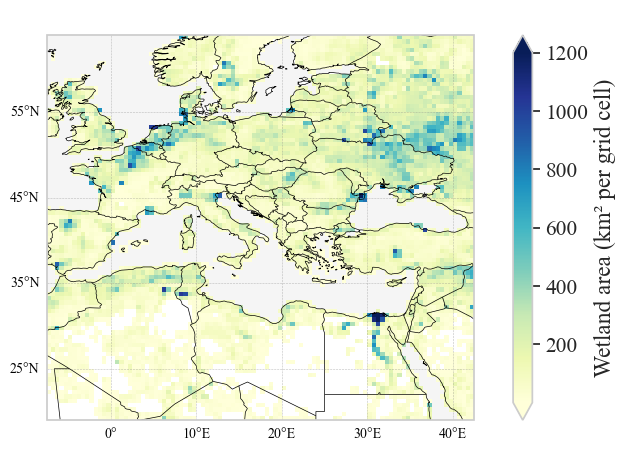

In [ ]:
ds = xr.open_dataset("data/wetland_loss_1700-2020_ensemblemean_v1.nc",decode_times=False)

# Select the 'wetland_area' variable from the dataset
nat_wet = ds['wetland_area']

# Get the data for the year 2020 (assuming the last time step is 2020)
# This selects the last element along the time dimension and all elements along lat and lon dimensions
nat_wet_2020 = nat_wet[-1,:,:]

# Replace zero values with nan
nat_wet_2020 = nat_wet_2020.where(nat_wet_2020 != 0, np.nan)


# Example data slicing (adjust as needed)
sea_reg_plot = nat_wet_2020[40:130, 345:445]

# 1. Create a figure and axis with a Cartopy projection
fig = plt.figure(figsize=(10, 5))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())

# 2. Add geographical features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='whitesmoke')

# 3. Plot the data
# Replace `sea_reg` with your actual data array.
# Make sure 'sea_reg' is an xarray DataArray or Dataset with coordinate dims named 'lat'/'lon'.
nat_wet_plot = sea_reg_plot.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu',
    robust=True,
    cbar_kwargs={'label': 'Wetland area (km² per grid cell)'},  
    vmin=1,
    vmax=1200
)

# 4. Set title
plt.title(" ")

# 5. Add subtle and updated gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Control longitude ticks
# gl.xlocator = mticker.FixedLocator([-30, -20, -10, 0, 10, 20, 30])
gl.xformatter = LONGITUDE_FORMATTER

# Control latitude ticks
gl.ylocator = mticker.FixedLocator([25, 35, 45, 55])
gl.yformatter = LATITUDE_FORMATTER

# Set label styles
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}

# Define the save path (update if needed)
save_path = r"C:\hula_data\data\figures\Figure-01.png"
plt.savefig(save_path, dpi=400, bbox_inches='tight')

# 6. Show the plot
plt.show()

### Figure S1

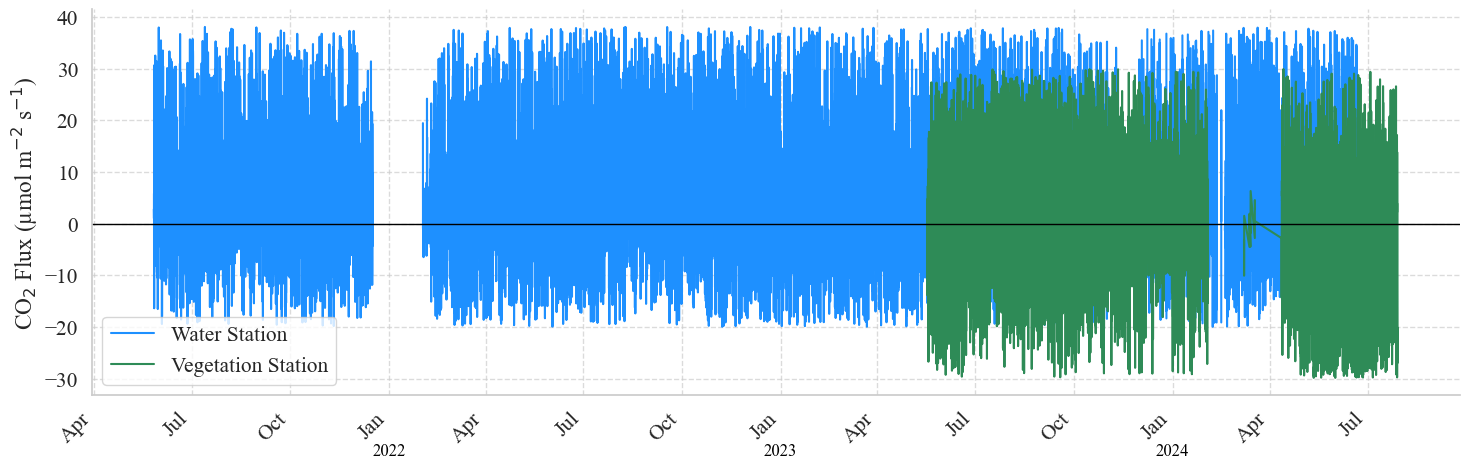

In [ ]:
# -------------------------------------------------------------------------------------------------
# GENERATE EXAMPLE DATA (Replace with your actual data as needed)
# -------------------------------------------------------------------------------------------------
x_water = water_df.index.to_pydatetime()
y_water = water_df['co2_flux'].values

x_veg = veg_df.index.to_pydatetime()
y_veg = veg_df['co2_flux'].values

# -------------------------------------------------------------------------------------------------
# CREATE FIGURE AND PLOT TIME SERIES FOR BOTH STATIONS
# -------------------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 5))

# Plot CO2 flux for Water Station
ax.plot(x_water, y_water, color='dodgerblue', label='Water Station')
# Plot CO2 flux for Vegetation Station
ax.plot(x_veg, y_veg, color='seagreen', label='Vegetation Station')

# -------------------------------------------------------------------------------------------------
# ADD BASELINE AND FORMAT THE AXES
# -------------------------------------------------------------------------------------------------
# Add a horizontal zero line
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('CO$_2$ Flux (µmol m$^{-2}$ s$^{-1}$)')

# Set major ticks every 3 months and format as abbreviated month names
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Set minor ticks at each year and format as full year
ax.xaxis.set_minor_locator(mdates.YearLocator())
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%Y'))

# Rotate month labels for better visibility
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Annotate the start of each year under the month labels
import datetime  # Ensure datetime is imported
for year in np.unique([dt.year for dt in x_water]):
    ax.annotate(str(year),
                xy=(mdates.date2num(datetime.datetime(year, 1, 1)), ax.get_ylim()[0]),
                xytext=(0, -40), textcoords='offset points',
                ha='center', va='center', fontsize=12, color='black')

# -------------------------------------------------------------------------------------------------
# FINALIZE THE PLOT STYLING AND SAVE THE FIGURE
# -------------------------------------------------------------------------------------------------
ax.grid(True, linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=6, width=1)
ax.legend()

plt.tight_layout()

# Define the save path (update if needed)
save_path = r"C:\hula_data\data\figures\Figure-S1.png"
plt.savefig(save_path, dpi=400, bbox_inches='tight')

plt.show()

### Figure 2

C:\Users\yaron\AppData\Local\Temp\ipykernel_12768\438728857.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


Figure saved to: figures/Figure-02.png


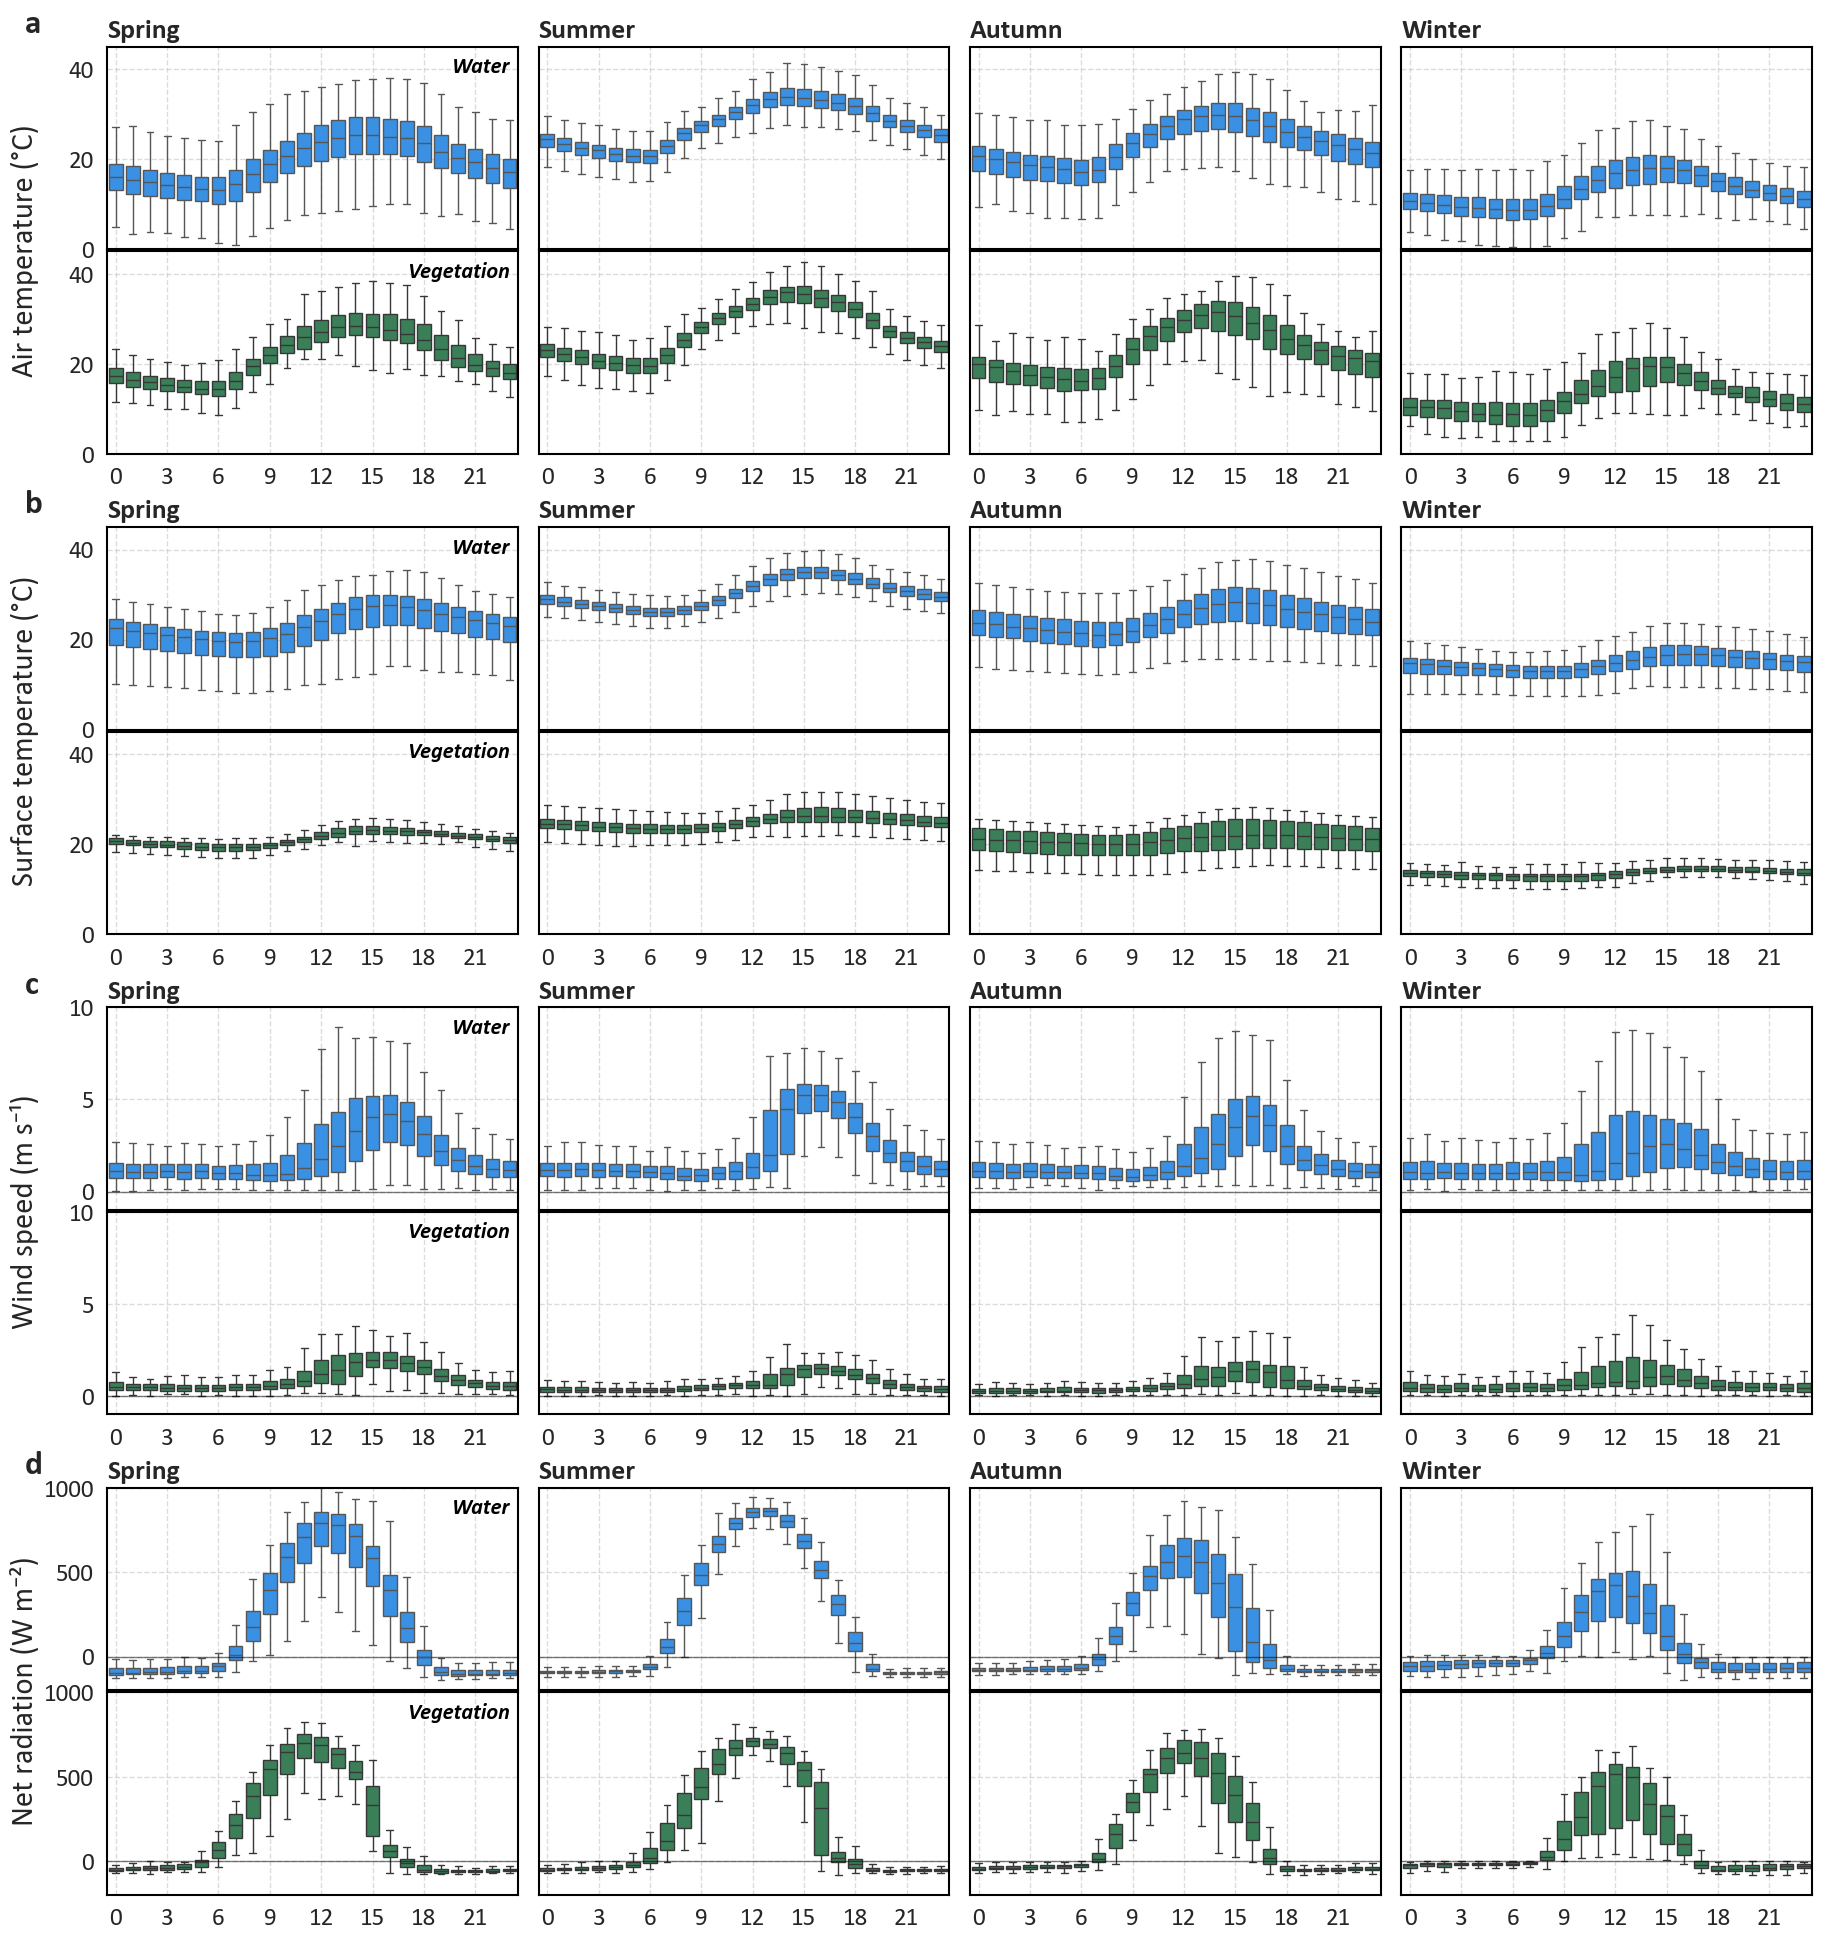

In [ ]:
def plot_seasonal_trends_fig2(parameters, labels, ylims=None, show_zero_line_params=None, path_to_save=None):
    """
    Creates seasonal boxplots of diurnal patterns for multiple parameters,
    with a polished design suitable for scientific publications.
    Figure 2: Air temperature, Surface temperature, Wind speed, and Net radiation.
    """
    
    # Set Calibri font for this figure only
    plt.rcParams['font.family'] = 'Calibri'
    
    seasons = {
        'Spring': [3, 4, 5],
        'Summer': range(6, 9),
        'Autumn': range(9, 12),
        'Winter': [12] + list(range(1, 3))
    }

    # Mapping for different column names between water and vegetation DataFrames
    column_mapping = {
        'Tsurf': {'water': 'Tw', 'veg': 'Ts'}
    }
    
    # Panel labels
    panel_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']

    num_params = len(parameters)
    
    fig = plt.figure(figsize=(22, 6 * num_params))
    
    outer_gs = gridspec.GridSpec(nrows=num_params, ncols=1, hspace=0.18, figure=fig)

    for param_idx, parameter in enumerate(parameters):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            nrows=2, ncols=4, subplot_spec=outer_gs[param_idx], hspace=0.01, wspace=0.05
        )

        # Create dummy axis for shared y-label
        dummy_ax = fig.add_subplot(inner_gs[:, 0])
        dummy_ax.tick_params(labelcolor="none", top=False, bottom=False, left=False, right=False)
        dummy_ax.patch.set_facecolor('none')
        for spine in dummy_ax.spines.values():
            spine.set_visible(False)
        dummy_ax.set_ylabel(labels[parameter], fontsize=22, labelpad=20)
        
        # Add panel label (a, b, c, d) aligned with y-axis label
        dummy_ax.text(-0.2, 1.02, panel_labels[param_idx], 
                    transform=dummy_ax.transAxes,
                    fontsize=24, 
                    fontweight='bold',
                    va='bottom',
                    ha='left')

        y_mins, y_maxs = [], []
        axes_water = []
        axes_veg = []

        # Get actual column names for this parameter
        if parameter in column_mapping:
            water_col = column_mapping[parameter]['water']
            veg_col = column_mapping[parameter]['veg']
        else:
            water_col = parameter
            veg_col = parameter

        for col, (season, months) in enumerate(seasons.items()):
            ax_water = fig.add_subplot(inner_gs[0, col])
            ax_veg = fig.add_subplot(inner_gs[1, col], sharex=ax_water)
            
            axes_water.append(ax_water)
            axes_veg.append(ax_veg)

            season_data_water = water_df[water_df.index.month.isin(months)]
            season_data_veg = veg_df[veg_df.index.month.isin(months)]
            
            def prepare_long_format_df(data, param):
                hourly_data_list = []
                for hour, group in data.groupby(data.index.hour)[param]:
                    values = group.dropna()
                    df = pd.DataFrame({'hour': hour, 'value': values})
                    hourly_data_list.append(df)
                if not hourly_data_list:
                    return pd.DataFrame(columns=['hour', 'value'])
                return pd.concat(hourly_data_list, ignore_index=True)

            # Use the correct column name for each DataFrame
            water_plot_df = prepare_long_format_df(season_data_water, water_col)
            veg_plot_df = prepare_long_format_df(season_data_veg, veg_col)
            
            sns.boxplot(x='hour', y='value', data=water_plot_df, ax=ax_water, color='dodgerblue', showfliers=False)
            sns.boxplot(x='hour', y='value', data=veg_plot_df, ax=ax_veg, color='seagreen', showfliers=False)

            for i, ax in enumerate([ax_water, ax_veg]):
                # Season title only on top row
                if i == 0:
                    ax.text(0.0, 1.02, season, 
                            transform=ax.transAxes, 
                            fontsize=20,
                            fontweight='bold', 
                            va='bottom',
                            ha='left')
                
                # Station name label - only in first column, top-right corner (BLACK color)
                if col == 0:
                    station_name = 'Water' if i == 0 else 'Vegetation'
                    ax.text(0.98, 0.95, station_name, 
                            transform=ax.transAxes, 
                            fontsize=16, 
                            fontweight='bold',
                            fontstyle='italic',
                            va='top',
                            ha='right',
                            color='black')
                
                # Hide x-tick labels for top row
                if i == 0:
                    plt.setp(ax.get_xticklabels(), visible=False)

                ax.grid(True, linestyle='--', alpha=0.7)
                
                # Show zero line only for specified parameters
                if show_zero_line_params and parameter in show_zero_line_params:
                    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
                
                for spine in ax.spines.values():
                    spine.set_edgecolor('black')
                    spine.set_linewidth(1.5)

                ax.set_ylabel("")

                # Hide y-tick labels for columns > 0
                if col > 0:
                    plt.setp(ax.get_yticklabels(), visible=False)
                
                ax.set_xlabel("")
                ax_veg.set_xticks(np.arange(0, 24, 3))
                
                ax.tick_params(axis='y', labelsize=18)
                ax_veg.tick_params(axis='x', labelsize=18)

                y_mins.append(ax.get_ylim()[0])
                y_maxs.append(ax.get_ylim()[1])

        # Set consistent y-limits
        if ylims and parameter in ylims:
            final_ylim = ylims[parameter]
        elif y_mins and y_maxs:
            y_min_final = min(y_mins)
            y_max_final = max(y_maxs)
            padding = (y_max_final - y_min_final) * 0.1
            final_ylim = (y_min_final - padding, y_max_final + padding)
        
        for ax in axes_water + axes_veg:
            ax.set_ylim(final_ylim)

    plt.tight_layout(pad=2.0)
    
    if path_to_save:
        fig.savefig(path_to_save, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {path_to_save}")

    plt.show()
    
    # Reset font to default after this figure
    plt.rcParams['font.family'] = plt.rcParamsDefault['font.family']


# --- Figure 2 Configuration ---
selected_cols = ['Ta', 'Tsurf', 'ws', 'Rn']

selected_labels = {
    'Ta': 'Air temperature (°C)',
    'Tsurf': 'Surface temperature (°C)', 
    'ws': 'Wind speed (m s⁻¹)',
    'Rn': 'Net radiation (W m⁻²)'
}

selected_ylims = {
    'Ta': (0, 45),
    'Tsurf': (0, 45),
    'ws': (-1, 10),  # Starting from -0.5
    'Rn': (-200, 1000)
}

# Parameters that should show y=0 line
zero_line_params = ['ws', 'Rn']

save_path = r"C:\hula_data\data\figures\Figure-02.png"

plot_seasonal_trends_fig2(
    parameters=selected_cols,
    labels=selected_labels,
    ylims=selected_ylims,
    show_zero_line_params=zero_line_params,
    path_to_save=save_path
)

### Figure 2 new version 

C:\Users\yaron\AppData\Local\Temp\ipykernel_12768\3959398517.py:429: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(
C:\Users\yaron\AppData\Local\Temp\ipykernel_12768\3959398517.py:448: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(


Combined Water–Vegetation figure saved to: data/figures/Figure-02-combined-water-vegetation.png


c:\Users\yaron\miniforge3\envs\geo_new\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


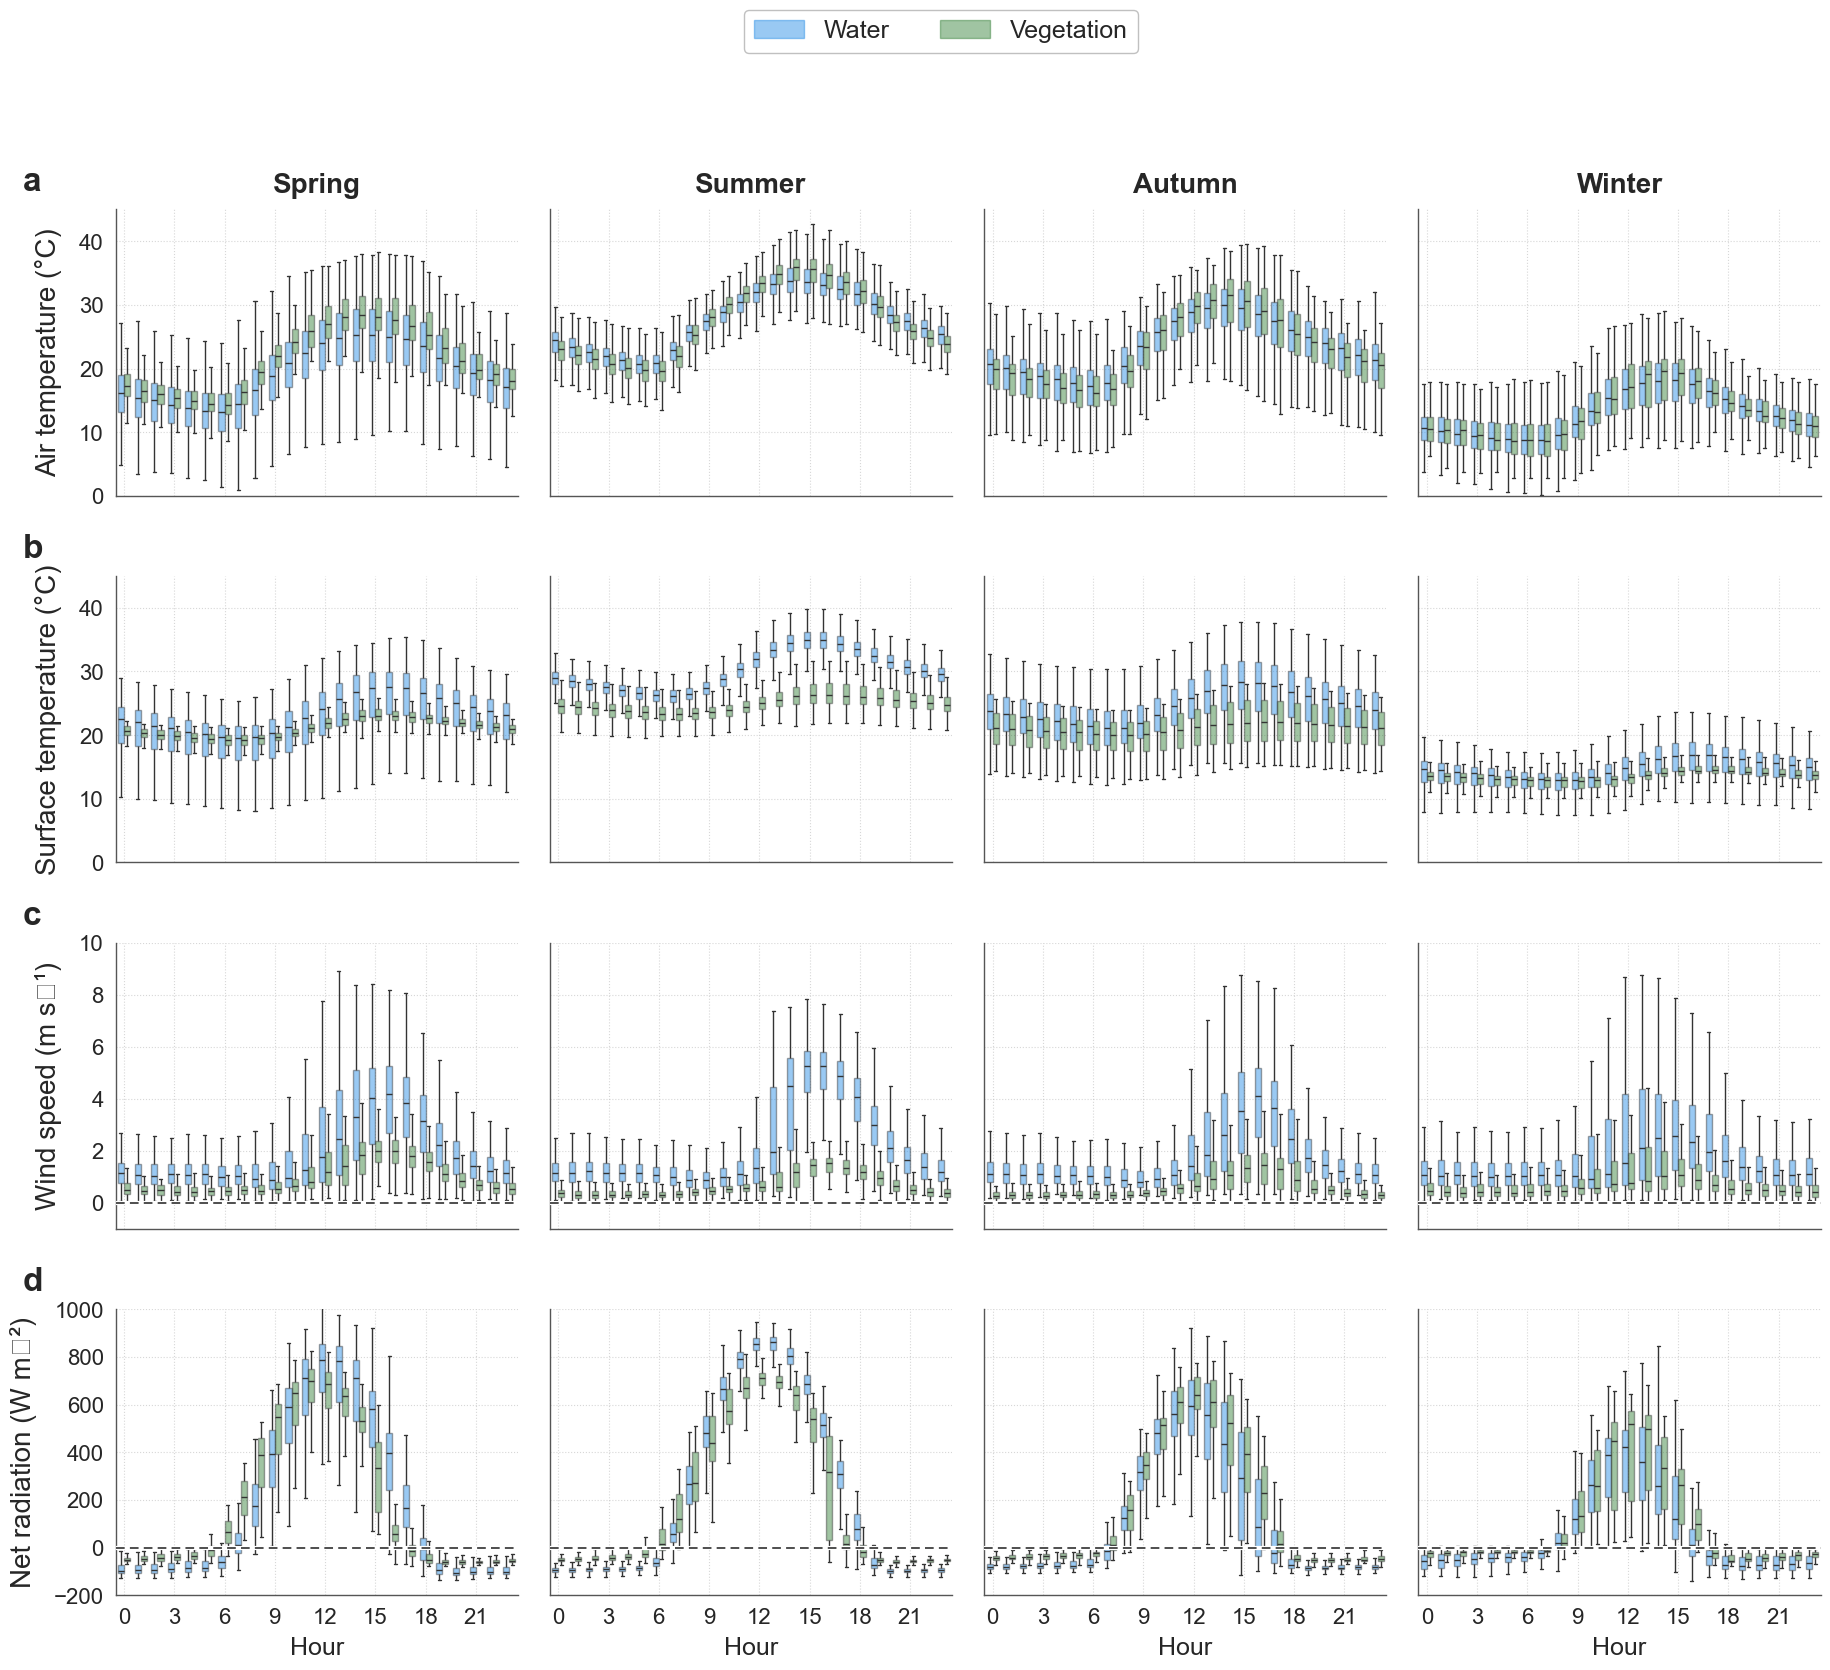

In [ ]:

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from matplotlib.patches import Patch


# ============================================================
# IMPORTANT
# ============================================================
# This code assumes that these two DataFrames already exist:
#
# water_df = ...
# veg_df = ...
#
# Both DataFrames must:
# 1. Use a DatetimeIndex.
# 2. Contain the variables listed below.
#
# Surface temperature columns:
#     water_df: "Tw"
#     veg_df:   "Ts"
# ============================================================


def plot_seasonal_trends_fig2(
    parameters,
    labels,
    ylims=None,
    show_zero_line_params=None,
    path_to_save=None,
    box_alpha=0.45
):
    """
    Create combined seasonal diurnal boxplots for Water and Vegetation.

    For each variable and season, Water and Vegetation are presented
    together as transparent, side-by-side hourly boxplots.

    Figure 2 variables:
        - Air temperature
        - Surface temperature
        - Wind speed
        - Net radiation
    """

    # --------------------------------------------------------
    # Figure settings
    # --------------------------------------------------------

    original_font = plt.rcParams["font.family"]
    plt.rcParams["font.family"] = "Calibri"

    sns.set_style("whitegrid")

    seasons = {
        "Spring": [3, 4, 5],
        "Summer": [6, 7, 8],
        "Autumn": [9, 10, 11],
        "Winter": [12, 1, 2]
    }

    # Different surface-temperature column names
    column_mapping = {
        "Tsurf": {
            "water": "Tw",
            "veg": "Ts"
        }
    }

    station_colors = {
        "Water": "#1E88E5",
        "Vegetation": "#2E7D32"
    }

    panel_labels = [
        "a", "b", "c", "d",
        "e", "f", "g", "h"
    ]

    num_params = len(parameters)
    num_seasons = len(seasons)

    if show_zero_line_params is None:
        show_zero_line_params = []

    # --------------------------------------------------------
    # Validate indices
    # --------------------------------------------------------

    if not isinstance(water_df.index, pd.DatetimeIndex):
        raise TypeError(
            "water_df must use a pandas DatetimeIndex."
        )

    if not isinstance(veg_df.index, pd.DatetimeIndex):
        raise TypeError(
            "veg_df must use a pandas DatetimeIndex."
        )

    water_data = water_df.sort_index().copy()
    veg_data = veg_df.sort_index().copy()

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig = plt.figure(
        figsize=(22, 4.5 * num_params)
    )

    outer_gs = gridspec.GridSpec(
        nrows=num_params,
        ncols=num_seasons,
        figure=fig,
        hspace=0.28,
        wspace=0.08
    )

    all_axes = []

    # --------------------------------------------------------
    # Helper: convert hourly data to long format
    # --------------------------------------------------------

    def prepare_long_format_df(data, column, station_name):
        if column not in data.columns:
            raise KeyError(
                f"Column '{column}' was not found in the "
                f"{station_name} DataFrame."
            )

        result = pd.DataFrame({
            "hour": data.index.hour,
            "value": pd.to_numeric(
                data[column],
                errors="coerce"
            ),
            "Station": station_name
        })

        result = result.dropna(subset=["value"])

        return result

    # --------------------------------------------------------
    # Plot each variable
    # --------------------------------------------------------

    for param_idx, parameter in enumerate(parameters):

        # Select correct column names
        if parameter in column_mapping:
            water_col = column_mapping[parameter]["water"]
            veg_col = column_mapping[parameter]["veg"]
        else:
            water_col = parameter
            veg_col = parameter

        parameter_axes = []

        for season_idx, (season, months) in enumerate(seasons.items()):

            ax = fig.add_subplot(
                outer_gs[param_idx, season_idx]
            )

            parameter_axes.append(ax)
            all_axes.append(ax)

            # ------------------------------------------------
            # Select seasonal data
            # ------------------------------------------------

            season_water = water_data.loc[
                water_data.index.month.isin(months)
            ]

            season_veg = veg_data.loc[
                veg_data.index.month.isin(months)
            ]

            # Convert both stations to long format
            water_plot_df = prepare_long_format_df(
                season_water,
                water_col,
                "Water"
            )

            veg_plot_df = prepare_long_format_df(
                season_veg,
                veg_col,
                "Vegetation"
            )

            combined_plot_df = pd.concat(
                [water_plot_df, veg_plot_df],
                ignore_index=True
            )

            # ------------------------------------------------
            # Combined Water + Vegetation boxplot
            # ------------------------------------------------

            if not combined_plot_df.empty:

                sns.boxplot(
                    data=combined_plot_df,
                    x="hour",
                    y="value",
                    hue="Station",
                    hue_order=["Water", "Vegetation"],
                    order=list(range(24)),
                    palette=station_colors,
                    dodge=True,
                    width=0.72,
                    linewidth=1.0,
                    showfliers=False,
                    saturation=1,
                    ax=ax
                )

                # Apply transparency to box colors
                for patch in ax.patches:
                    patch.set_alpha(box_alpha)

                # Remove individual subplot legends
                subplot_legend = ax.get_legend()

                if subplot_legend is not None:
                    subplot_legend.remove()

            # ------------------------------------------------
            # Season titles
            # ------------------------------------------------

            if param_idx == 0:
                ax.set_title(
                    season,
                    fontsize=20,
                    fontweight="bold",
                    pad=12
                )

            # ------------------------------------------------
            # Panel labels
            # ------------------------------------------------

            if season_idx == 0:
                ax.text(
                    -0.23,
                    1.04,
                    panel_labels[param_idx],
                    transform=ax.transAxes,
                    fontsize=24,
                    fontweight="bold",
                    va="bottom",
                    ha="left",
                    clip_on=False
                )

            # ------------------------------------------------
            # Axis labels
            # ------------------------------------------------

            if season_idx == 0:
                ax.set_ylabel(
                    labels[parameter],
                    fontsize=20,
                    labelpad=12
                )
            else:
                ax.set_ylabel("")
                ax.tick_params(
                    axis="y",
                    labelleft=False
                )

            if param_idx == num_params - 1:
                ax.set_xlabel(
                    "Hour",
                    fontsize=18,
                    labelpad=7
                )
            else:
                ax.set_xlabel("")
                ax.tick_params(
                    axis="x",
                    labelbottom=False
                )

            # Show every third hour
            ax.set_xticks(
                np.arange(0, 24, 3)
            )

            ax.set_xticklabels(
                [str(hour) for hour in range(0, 24, 3)]
            )

            # ------------------------------------------------
            # Zero reference line
            # ------------------------------------------------

            if parameter in show_zero_line_params:

                # White separation beneath zero line
                ax.axhline(
                    y=0,
                    color="white",
                    linewidth=3.0,
                    linestyle="-",
                    zorder=7
                )

                # Dark dashed zero line
                ax.axhline(
                    y=0,
                    color="#222222",
                    linewidth=1.25,
                    linestyle="--",
                    dashes=(5, 3),
                    alpha=0.90,
                    zorder=8
                )

            # ------------------------------------------------
            # Styling
            # ------------------------------------------------

            ax.grid(
                True,
                axis="both",
                linestyle=":",
                color="#BDBDBD",
                linewidth=0.8,
                alpha=0.60
            )

            ax.tick_params(
                axis="both",
                labelsize=16,
                direction="out",
                length=5,
                width=1
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.spines["left"].set_color("#555555")
            ax.spines["bottom"].set_color("#555555")

            ax.spines["left"].set_linewidth(1.0)
            ax.spines["bottom"].set_linewidth(1.0)

        # ----------------------------------------------------
        # Apply common y-limit to all seasons for this variable
        # ----------------------------------------------------

        if ylims is not None and parameter in ylims:
            final_ylim = ylims[parameter]

        else:
            current_limits = [
                axis.get_ylim()
                for axis in parameter_axes
            ]

            minimum = min(
                limit[0] for limit in current_limits
            )

            maximum = max(
                limit[1] for limit in current_limits
            )

            data_range = maximum - minimum

            if data_range == 0:
                data_range = 1

            padding = data_range * 0.05

            final_ylim = (
                minimum - padding,
                maximum + padding
            )

        for axis in parameter_axes:
            axis.set_ylim(final_ylim)

    # --------------------------------------------------------
    # Shared legend
    # --------------------------------------------------------

    legend_handles = [
        Patch(
            facecolor=station_colors["Water"],
            edgecolor=station_colors["Water"],
            alpha=box_alpha,
            label="Water"
        ),
        Patch(
            facecolor=station_colors["Vegetation"],
            edgecolor=station_colors["Vegetation"],
            alpha=box_alpha,
            label="Vegetation"
        )
    ]

    fig.legend(
        handles=legend_handles,
        labels=["Water", "Vegetation"],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.998),
        ncol=2,
        fontsize=18,
        frameon=True,
        facecolor="white",
        edgecolor="#BDBDBD",
        framealpha=0.95
    )

    # Leave room for shared legend
    plt.tight_layout(
        rect=[0.02, 0.02, 1.00, 0.965],
        pad=1.5
    )

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    if path_to_save:

        output_directory = os.path.dirname(path_to_save)

        if output_directory:
            os.makedirs(
                output_directory,
                exist_ok=True
            )

        fig.savefig(
            path_to_save,
            dpi=400,
            bbox_inches="tight",
            facecolor="white"
        )

        print(
            f"Combined Water–Vegetation figure saved to: "
            f"{path_to_save}"
        )

    plt.show()

    # Restore original font
    plt.rcParams["font.family"] = original_font


# ============================================================
# FIGURE 2 CONFIGURATION
# ============================================================

selected_cols = [
    "Ta",
    "Tsurf",
    "ws",
    "Rn"
]

selected_labels = {
    "Ta": "Air temperature (°C)",
    "Tsurf": "Surface temperature (°C)",
    "ws": "Wind speed (m s⁻¹)",
    "Rn": "Net radiation (W m⁻²)"
}

selected_ylims = {
    "Ta": (0, 45),
    "Tsurf": (0, 45),
    "ws": (-1, 10),
    "Rn": (-200, 1000)
}

# Variables requiring a visible zero reference line
zero_line_params = [
    "ws",
    "Rn"
]

save_path = (
    r"data/figures/"
    r"Figure-02-combined-water-vegetation.png"
)


# ============================================================
# RUN FIGURE 2
# ============================================================

plot_seasonal_trends_fig2(
    parameters=selected_cols,
    labels=selected_labels,
    ylims=selected_ylims,
    show_zero_line_params=zero_line_params,
    path_to_save=save_path,
    box_alpha=0.45
)

### Figure 3 

Number of days per season - Water Station: {'spring': 60, 'summer': 92, 'autumn': 91, 'winter': 61}
Number of days per season - Vegetation Station: {'spring': 60, 'summer': 92, 'autumn': 91, 'winter': 61}

In [ ]:
# Count the number of unique days of data in each season for both stations

# Define seasons as month lists
seasons = {
    'spring': [3, 4, 5],
    'summer': [6, 7, 8],
    'autumn': [9, 10, 11],
    'winter': [12, 1, 2]
}

def count_days_per_season(df, seasons_dict):
    results = {}
    for season, months in seasons_dict.items():
        # Filter data for the season
        season_df = df[df.index.month.isin(months)]
        # Count unique days (date only, not time)
        unique_days = season_df.index.normalize().unique()
        results[season] = len(unique_days)
    return results

# Count for water and vegetation stations
water_days_per_season = count_days_per_season(water_df, seasons)
veg_days_per_season = count_days_per_season(veg_df, seasons)

print("Number of data days per season - Water Station:", water_days_per_season)
print("Number of data days per season - Vegetation Station:", veg_days_per_season)


def percent_data_per_season(df, seasons_dict):
    total_count = len(df)
    percentages = {}
    for season, months in seasons_dict.items():
        season_count = len(df[df.index.month.isin(months)])
        percentages[season] = round(100 * season_count / total_count, 2) if total_count > 0 else 0
    return percentages

water_percent_per_season = percent_data_per_season(water_df, seasons)
veg_percent_per_season = percent_data_per_season(veg_df, seasons)

print("Percentage of data points per season - Water Station:", water_percent_per_season)
print("Percentage of data points per season - Vegetation Station:", veg_percent_per_season)

Number of data days per season - Water Station: {'spring': 282, 'summer': 296, 'autumn': 272, 'winter': 270}
Number of data days per season - Vegetation Station: {'spring': 70, 'summer': 150, 'autumn': 91, 'winter': 65}
Percentage of data points per season - Water Station: {'spring': 25.4, 'summer': 26.63, 'autumn': 24.15, 'winter': 23.82}
Percentage of data points per season - Vegetation Station: {'spring': 17.23, 'summer': 40.85, 'autumn': 24.65, 'winter': 17.27}


### Figure 3

C:\Users\yaron\AppData\Local\Temp\ipykernel_12768\1058780314.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


Figure saved to: figures/Figure-03.png


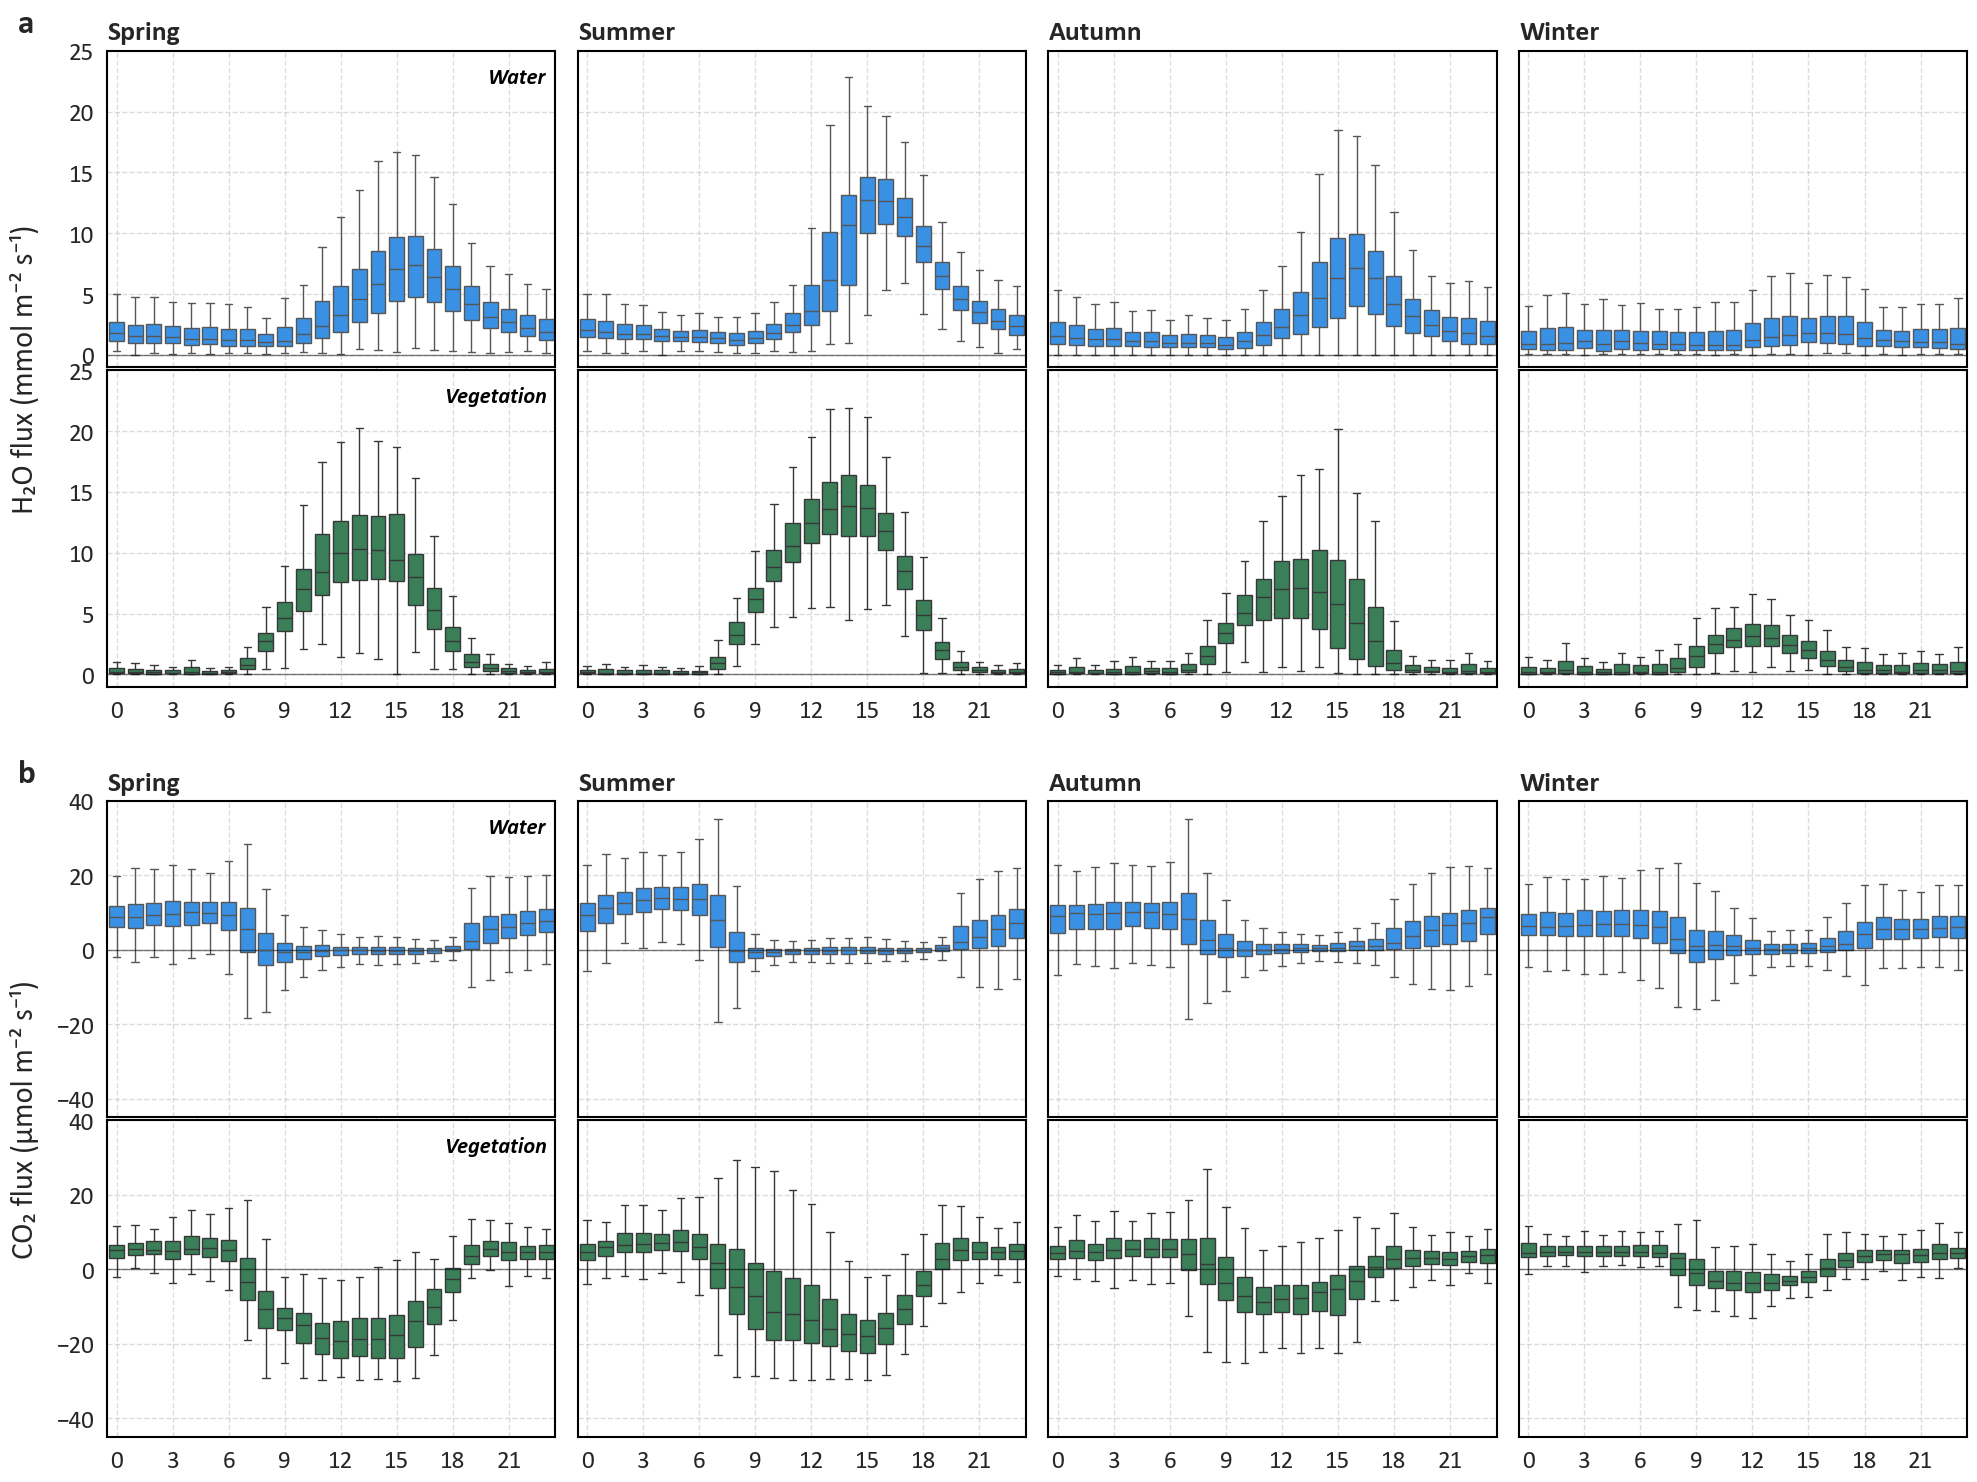

In [ ]:
def plot_seasonal_trends_fig3(parameters, labels, ylims=None, show_zero_line_params=None, path_to_save=None):
    """
    Creates seasonal boxplots of diurnal patterns for H2O and CO2 fluxes,
    with a polished design matching Figure 2 style.
    Figure 3: H2O flux and CO2 flux.
    """
    
    # Set Calibri font for this figure only
    plt.rcParams['font.family'] = 'Calibri'
    
    seasons = {
        'Spring': [3, 4, 5],
        'Summer': range(6, 9),
        'Autumn': range(9, 12),
        'Winter': [12] + list(range(1, 3))
    }
    
    # Panel labels
    panel_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']

    num_params = len(parameters)
    
    fig = plt.figure(figsize=(24, 9 * num_params))
    
    outer_gs = gridspec.GridSpec(nrows=num_params, ncols=1, hspace=0.18, figure=fig)

    for param_idx, parameter in enumerate(parameters):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            nrows=2, ncols=4, subplot_spec=outer_gs[param_idx], hspace=0.01, wspace=0.05
        )

        # Create dummy axis for shared y-label
        dummy_ax = fig.add_subplot(inner_gs[:, 0])
        dummy_ax.tick_params(labelcolor="none", top=False, bottom=False, left=False, right=False)
        dummy_ax.patch.set_facecolor('none')
        for spine in dummy_ax.spines.values():
            spine.set_visible(False)
        dummy_ax.set_ylabel(labels[parameter], fontsize=22, labelpad=20)
        
        # Add panel label (a, b) aligned with y-axis label
        dummy_ax.text(-0.2, 1.02, panel_labels[param_idx], 
                      transform=dummy_ax.transAxes,
                      fontsize=24, 
                      fontweight='bold',
                      va='bottom',
                      ha='left')

        y_mins, y_maxs = [], []
        axes_water = []
        axes_veg = []

        for col, (season, months) in enumerate(seasons.items()):
            ax_water = fig.add_subplot(inner_gs[0, col])
            ax_veg = fig.add_subplot(inner_gs[1, col], sharex=ax_water)
            
            axes_water.append(ax_water)
            axes_veg.append(ax_veg)

            season_data_water = water_df[water_df.index.month.isin(months)]
            season_data_veg = veg_df[veg_df.index.month.isin(months)]
            
            def prepare_long_format_df(data, param, filter_positive=False):
                hourly_data_list = []
                for hour, group in data.groupby(data.index.hour)[param]:
                    values = group.dropna()
                    # Filter for positive values only if specified
                    if filter_positive:
                        values = values[values > 0]
                    df = pd.DataFrame({'hour': hour, 'value': values})
                    hourly_data_list.append(df)
                if not hourly_data_list:
                    return pd.DataFrame(columns=['hour', 'value'])
                return pd.concat(hourly_data_list, ignore_index=True)

            # For h2o_flux, filter to include only values > 0
            filter_positive = (parameter == 'h2o_flux')
            water_plot_df = prepare_long_format_df(season_data_water, parameter, filter_positive=filter_positive)
            veg_plot_df = prepare_long_format_df(season_data_veg, parameter, filter_positive=filter_positive)
            
            sns.boxplot(x='hour', y='value', data=water_plot_df, ax=ax_water, color='dodgerblue', showfliers=False)
            sns.boxplot(x='hour', y='value', data=veg_plot_df, ax=ax_veg, color='seagreen', showfliers=False)

            for i, ax in enumerate([ax_water, ax_veg]):
                # Season title only on top row
                if i == 0:
                    ax.text(0.0, 1.02, season, 
                            transform=ax.transAxes, 
                            fontsize=20,
                            fontweight='bold', 
                            va='bottom',
                            ha='left')
                
                # Station name label - only in first column, top-right corner
                if col == 0:
                    station_name = 'Water' if i == 0 else 'Vegetation'
                    ax.text(0.98, 0.95, station_name, 
                            transform=ax.transAxes, 
                            fontsize=16, 
                            fontweight='bold',
                            fontstyle='italic',
                            va='top',
                            ha='right',
                            color='black')
                
                # Hide x-tick labels for top row
                if i == 0:
                    plt.setp(ax.get_xticklabels(), visible=False)

                ax.grid(True, linestyle='--', alpha=0.7)
                
                # Show zero line only for specified parameters
                if show_zero_line_params and parameter in show_zero_line_params:
                    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
                
                for spine in ax.spines.values():
                    spine.set_edgecolor('black')
                    spine.set_linewidth(1.5)

                ax.set_ylabel("")

                # Hide y-tick labels for columns > 0
                if col > 0:
                    plt.setp(ax.get_yticklabels(), visible=False)
                
                ax.set_xlabel("")
                ax_veg.set_xticks(np.arange(0, 24, 3))
                
                ax.tick_params(axis='y', labelsize=18)
                ax_veg.tick_params(axis='x', labelsize=18)

                y_mins.append(ax.get_ylim()[0])
                y_maxs.append(ax.get_ylim()[1])

        # Set consistent y-limits
        if ylims and parameter in ylims:
            final_ylim = ylims[parameter]
        elif y_mins and y_maxs:
            y_min_final = min(y_mins)
            y_max_final = max(y_maxs)
            padding = (y_max_final - y_min_final) * 0.1
            final_ylim = (y_min_final - padding, y_max_final + padding)
        
        for ax in axes_water + axes_veg:
            ax.set_ylim(final_ylim)

    plt.tight_layout(pad=2.0)
    
    if path_to_save:
        fig.savefig(path_to_save, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {path_to_save}")

    plt.show()
    
    # Reset font to default after this figure
    plt.rcParams['font.family'] = plt.rcParamsDefault['font.family']


# --- Figure 3 Configuration ---
selected_cols = ['h2o_flux', 'co2_flux']

selected_labels = {
    'h2o_flux': 'H₂O flux (mmol m⁻² s⁻¹)',
    'co2_flux': 'CO₂ flux (μmol m⁻² s⁻¹)'
}

# Adjust ylims based on your corrected data
selected_ylims = {
    'h2o_flux': (-1, 25),  # Adjust after checking corrected values
    'co2_flux': (-45, 40)   # Adjust as needed
}

# Parameters that should show y=0 line
zero_line_params = ['h2o_flux', 'co2_flux']

save_path = r"C:\hula_data\data\figures\Figure-03.png"

plot_seasonal_trends_fig3(
    parameters=selected_cols,
    labels=selected_labels,
    ylims=selected_ylims,
    show_zero_line_params=zero_line_params,
    path_to_save=save_path
)

### Figure 3 3 new verion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

water_df = pd.read_csv(r'C:\hula_data\data\water_df_for_plot_03.csv', parse_dates=['time']).set_index('time')
veg_df = pd.read_csv(r'C:\hula_data\data\veg_df_for_plot_03.csv', parse_dates=['time']).set_index('time')

# water_df has no h2o_flux column (only LE, W m-2) -> convert using
# standard latent heat of vaporization (2453 J/g) and molar mass of water
# (18.015 g/mol) so both stations are in mmol m-2 s-1
LAMBDA_J_PER_G = 2453.0
MOLAR_MASS_H2O = 18.015
J_PER_MMOL = LAMBDA_J_PER_G * (MOLAR_MASS_H2O / 1000.0)  # J per mmol H2O
water_df['h2o_flux'] = water_df['LE'] / J_PER_MMOL

seasons = {
    'Spring': [3, 4, 5],
    'Summer': range(6, 9),
    'Autumn': range(9, 12),
    'Winter': [12] + list(range(1, 3))
}

parameters = ['h2o_flux', 'co2_flux']
labels = {
    'h2o_flux': 'H$_2$O flux (mmol m$^{-2}$ s$^{-1}$)',
    'co2_flux': 'CO$_2$ flux (µmol m$^{-2}$ s$^{-1}$)',
}
ylims = {'h2o_flux': (0, 22), 'co2_flux': (-45, 45)}
zero_line_params = {'h2o_flux', 'co2_flux'}
panel_labels = ['a', 'b']


def prep_long(data, param, station_label, filter_positive=False):
    rows = []
    for hour, group in data.groupby(data.index.hour)[param]:
        v = group.dropna()
        if filter_positive:
            v = v[v > 0]
        rows.append(pd.DataFrame({'hour': hour, 'value': v, 'station': station_label}))
    if not rows:
        return pd.DataFrame(columns=['hour', 'value', 'station'])
    return pd.concat(rows, ignore_index=True)


def make_figure(box_alpha, out_path):
    fig = plt.figure(figsize=(22, 5.2 * len(parameters) + 1))
    outer_gs = gridspec.GridSpec(nrows=len(parameters), ncols=4, hspace=0.28, wspace=0.05,
                                  top=0.90, bottom=0.10, left=0.06, right=0.99, figure=fig)

    for r, param in enumerate(parameters):
        for c, (season, months) in enumerate(seasons.items()):
            ax = fig.add_subplot(outer_gs[r, c])

            if param in zero_line_params:
                ax.axhline(0, color='black', lw=1, ls='--', alpha=0.6, zorder=0.5)

            w = water_df[water_df.index.month.isin(months)]
            v = veg_df[veg_df.index.month.isin(months)]
            fp = (param == 'h2o_flux')
            combined = pd.concat([
                prep_long(w, param, 'Water', fp),
                prep_long(v, param, 'Vegetation', fp)
            ], ignore_index=True)

            sns.boxplot(x='hour', y='value', hue='station', data=combined, ax=ax,
                        palette={'Water': 'dodgerblue', 'Vegetation': 'seagreen'},
                        showfliers=False, width=0.7, linewidth=0.8, gap=0.1,
                        zorder=2)

            if box_alpha < 1.0:
                for patch in ax.patches:
                    r_, g_, b_, a_ = patch.get_facecolor()
                    patch.set_facecolor((r_, g_, b_, box_alpha))

            ax.get_legend().remove()

            ax.set_title(season, fontsize=18, fontweight='bold', pad=10)
            if c == 0:
                ax.set_ylabel(labels[param], fontsize=15)
                ax.text(-0.22, 1.05, panel_labels[r], transform=ax.transAxes,
                        fontsize=20, fontweight='bold', va='bottom', ha='left')
            else:
                ax.set_ylabel("")
                plt.setp(ax.get_yticklabels(), visible=False)

            ax.set_xticks(np.arange(0, 24, 3))
            ax.set_xticklabels(np.arange(0, 24, 3), fontsize=10)
            if r == len(parameters) - 1:
                ax.set_xlabel('Hour', fontsize=14)
            else:
                ax.set_xlabel("")

            ax.set_ylim(ylims[param])
            for spine in ax.spines.values():
                spine.set_edgecolor('black')
                spine.set_linewidth(1.2)
            ax.tick_params(labelsize=11)

    legend_elems = [Patch(facecolor='dodgerblue', edgecolor='black', label='Water', alpha=box_alpha),
                    Patch(facecolor='seagreen', edgecolor='black', label='Vegetation', alpha=box_alpha)]
    fig.legend(handles=legend_elems, loc='upper center', ncol=2, fontsize=15, frameon=True,
               bbox_to_anchor=(0.5, 1.0))

    plt.savefig(out_path, dpi=400, bbox_inches='tight')
    plt.close(fig)


make_figure(box_alpha=1.0, out_path=r'C:\hula_data\data\figures\Figure-03-CO2-H2O-flux-solid_400dpi.png')
make_figure(box_alpha=0.6, out_path=r'C:\hula_data\data\figures\Figure-03-CO2-H2O-flux-transparent_400dpi.png')

print("saved both versions")

saved both versions


In [ ]:
# Define seasons and initialize lists to store the results
seasons = {
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Autumn': [9, 10, 11],
    'Winter': [12, 1, 2]
}
results_list_mean = []
results_list_median = []

# --- Process Seasonal Data ---
for season_name, months in seasons.items():
    season_data_mean = {'Season': season_name}
    season_data_median = {'Season': season_name}
    
    for station_label, df in [('Water Station', water_df), ('Vegetation Station', veg_df)]:
        season_df = df[df.index.month.isin(months)]
        
        if not season_df.empty:
            grouped = season_df.groupby(season_df.index.hour)['h2o_flux']
            
            # Calculate Mean and Std
            means = grouped.mean()
            stds = grouped.std()
            if not means.empty:
                max_hour_mean = means.idxmax()
                max_mean = means.loc[max_hour_mean]
                max_std = stds.loc[max_hour_mean]
                season_data_mean[station_label] = f"{max_mean:.2f} ± {max_std:.2f} @ {max_hour_mean:02d}:00"
            else:
                season_data_mean[station_label] = "N/A"

            # Calculate Median and IQR
            medians = grouped.median()
            q1 = grouped.quantile(0.25)
            q3 = grouped.quantile(0.75)
            iqrs = q3 - q1
            if not medians.empty:
                max_hour_median = medians.idxmax()
                peak_median = medians.loc[max_hour_median]
                peak_iqr = iqrs.loc[max_hour_median]
                season_data_median[station_label] = f"{peak_median:.2f} ({peak_iqr:.2f}) @ {max_hour_median:02d}:00"
            else:
                season_data_median[station_label] = "N/A"
        else:
            season_data_mean[station_label] = "N/A"
            season_data_median[station_label] = "N/A"
            
    results_list_mean.append(season_data_mean)
    results_list_median.append(season_data_median)

# --- Process Annual Data ---
total_data_mean = {'Season': 'Annual'}
total_data_median = {'Season': 'Annual'}

for station_label, df in [('Water Station', water_df), ('Vegetation Station', veg_df)]:
    grouped = df.groupby(df.index.hour)['h2o_flux']
    
    # Calculate Mean and Std
    means = grouped.mean()
    stds = grouped.std()
    max_hour_mean = means.idxmax()
    max_mean = means.loc[max_hour_mean]
    max_std = stds.loc[max_hour_mean]
    total_data_mean[station_label] = f"{max_mean:.2f} ± {max_std:.2f} @ {max_hour_mean:02d}:00"

    # Calculate Median and IQR
    medians = grouped.median()
    q1 = grouped.quantile(0.25)
    q3 = grouped.quantile(0.75)
    iqrs = q3 - q1
    max_hour_median = medians.idxmax()
    peak_median = medians.loc[max_hour_median]
    peak_iqr = iqrs.loc[max_hour_median]
    total_data_median[station_label] = f"{peak_median:.2f} ({peak_iqr:.2f}) @ {max_hour_median:02d}:00"

results_list_mean.append(total_data_mean)
results_list_median.append(total_data_median)

# --- Create and Display DataFrames ---
# Mean and Std Deviation Table
summary_df_mean = pd.DataFrame(results_list_mean).set_index('Season')
print("Table: Peak H₂O Flux (Mean ± Std Dev)")
display(summary_df_mean)

# Median and IQR Table
summary_df_median = pd.DataFrame(results_list_median).set_index('Season')
print("\nTable: Peak H₂O Flux (Median (IQR))")
display(summary_df_median)

Table: Peak H₂O Flux (Mean ± Std Dev)


,Water Station,Vegetation Station
Season,,
Spring,7.06 ± 3.53 @ 16:00,10.71 ± 3.74 @ 13:00
Summer,12.27 ± 2.71 @ 16:00,13.77 ± 4.20 @ 14:00
Autumn,6.38 ± 3.86 @ 16:00,7.33 ± 3.47 @ 13:00
Winter,1.95 ± 1.82 @ 14:00,3.83 ± 3.98 @ 13:00
Annual,7.01 ± 4.80 @ 16:00,9.96 ± 5.32 @ 13:00



Table: Peak H₂O Flux (Median (IQR))


,Water Station,Vegetation Station
Season,,
Spring,7.00 (4.92) @ 16:00,10.30 (5.38) @ 13:00
Summer,12.57 (3.44) @ 16:00,13.88 (5.04) @ 14:00
Autumn,6.37 (6.46) @ 16:00,7.21 (4.81) @ 13:00
Winter,1.46 (2.07) @ 15:00,3.13 (1.83) @ 12:00
Annual,6.74 (8.77) @ 16:00,10.37 (9.44) @ 14:00


### Table 1 + Table 2

In [ ]:
def check_normality(data, alpha=0.05):
    """
    Check if data follows normal distribution using Shapiro-Wilk test.
    Returns True if normal, False otherwise.
    """
    if len(data) < 3:
        return False
    try:
        stat, p_value = shapiro(data.dropna())
        return p_value > alpha
    except:
        return False

def perform_statistical_test(data1, data2, alpha=0.05):
    """
    Perform appropriate statistical test between two datasets.
    Uses t-test for normal data, Mann-Whitney U for non-normal data.
    Returns significance letters and p-value.
    """
    from scipy.stats import mannwhitneyu
    
    # Remove NaN values
    data1_clean = data1.dropna()
    data2_clean = data2.dropna()
    
    if len(data1_clean) < 2 or len(data2_clean) < 2:
        return 'a', 'a', 1.0, 'insufficient_data'
    
    # Check normality
    data1_normal = check_normality(data1_clean)
    data2_normal = check_normality(data2_clean)
    
    try:
        if data1_normal and data2_normal:
            # Use t-test for normal data
            levene_stat, levene_p = stats.levene(data1_clean, data2_clean)
            equal_var = levene_p > alpha
            t_stat, p_value = ttest_ind(data1_clean, data2_clean, equal_var=equal_var)
            test_used = 't-test'
        else:
            # Use Mann-Whitney U test for non-normal data
            stat, p_value = mannwhitneyu(data1_clean, data2_clean, alternative='two-sided')
            test_used = 'Mann-Whitney U'
        
        # Assign significance letters
        if p_value < alpha:
            # Determine which group has higher mean/median
            if data1_clean.median() > data2_clean.median():
                return 'a', 'b', p_value, test_used
            else:
                return 'b', 'a', p_value, test_used
        else:
            return 'a', 'a', p_value, test_used
            
    except Exception as e:
        print(f"Error in statistical test: {e}")
        return 'a', 'a', 1.0, 'error'


def create_parameter_tables():
    """
    Create two separate statistics tables:
    1. For Tair, Tsurf, and Wind speed
    2. For H2O and CO2 fluxes
    Returns both tables as DataFrames.
    """
    print("Creating Parameter Tables")
    print("=" * 60)
    
    # Define seasons
    seasons = {
        'Spring': [3, 4, 5],
        'Summer': [6, 7, 8],
        'Autumn': [9, 10, 11],
        'Winter': [12, 1, 2]
    }
    
    # Table 1: Temperature and Wind Parameters
    # Note: Water station uses 'Tw' while vegetation station uses 'Ts'
    table1_parameters = [
        ('Ta', 'Ta'),     # Air temperature - same in both datasets
        ('Ts', 'Tw'),     # Surface temp: 'Ts' in veg, 'Tw' in water
        ('ws', 'ws'),     # Wind speed - same in both datasets
        ('Rn', 'Rn')      # Net radiation - same in both datasets
    ]
    table1_labels = {
        'Ta': 'Tair (°C)',
        'Ts': 'Tsurf (°C)', 
        'ws': 'Wind speed (m s⁻¹)',
        'Rn': 'Net radiation (W m⁻²)'
    }
    
    # Table 2: Flux Parameters 
    # Note: Using h2o_flux (converted from ET to mmol m⁻² s⁻¹)
    table2_parameters = [
        ('h2o_flux', 'h2o_flux'),        # H2O flux for both vegetation and water
        ('co2_flux', 'co2_flux')
    ]
    table2_labels = {
        'h2o_flux': 'H₂O (mmol m⁻² s⁻¹)',  # H2O flux units
        'co2_flux': 'CO₂ (μmol m⁻² s⁻¹)'
    }

    def create_table(parameters, labels, table_name):
        results_list = []
        
        for param_info in parameters:
            if isinstance(param_info, tuple):
                veg_param, water_param = param_info
                display_param = veg_param  # Use veg parameter name for display
            else:
                veg_param = water_param = display_param = param_info
            
            print(f"\nProcessing {labels[display_param]}...")
            
            # Check if parameters exist in datasets
            if water_param not in water_df.columns:
                print(f"Warning: {water_param} not found in water dataset")
                continue
            if veg_param not in veg_df.columns:
                print(f"Warning: {veg_param} not found in vegetation dataset")
                continue
            
            # Process each season
            for season_name, months in seasons.items():
                # Filter data by season
                water_season = water_df[water_df.index.month.isin(months)][water_param]
                veg_season = veg_df[veg_df.index.month.isin(months)][veg_param]
                
                # Calculate statistics
                water_mean = water_season.mean()
                water_std = water_season.std()
                veg_mean = veg_season.mean()
                veg_std = veg_season.std()
                
                # Check normality and perform statistical test
                water_normal = check_normality(water_season)
                veg_normal = check_normality(veg_season)
                water_sig, veg_sig, p_value, test_used = perform_statistical_test(water_season, veg_season)
                
                # Add to results list
                results_list.append({
                    'Parameter': labels[display_param],
                    'Season': season_name,
                    'Water_Mean': round(water_mean, 2),
                    'Water_Std': round(water_std, 2),
                    'Water_Sig': water_sig,
                    'Water_Formatted': f"{water_mean:.2f} ± {water_std:.2f}{water_sig}",
                    'Veg_Mean': round(veg_mean, 2),
                    'Veg_Std': round(veg_std, 2),
                    'Veg_Sig': veg_sig,
                    'Veg_Formatted': f"{veg_mean:.2f} ± {veg_std:.2f}{veg_sig}",
                    'P_Value': round(p_value, 4),
                    'Test_Used': test_used,
                    'Both_Normal': water_normal and veg_normal
                })
            
            # Annual statistics
            water_annual = water_df[water_param]
            veg_annual = veg_df[veg_param]
            
            water_annual_mean = water_annual.mean()
            water_annual_std = water_annual.std()
            veg_annual_mean = veg_annual.mean()
            veg_annual_std = veg_annual.std()
            
            water_annual_normal = check_normality(water_annual)
            veg_annual_normal = check_normality(veg_annual)
            water_annual_sig, veg_annual_sig, annual_p_value, annual_test_used = perform_statistical_test(water_annual, veg_annual)
            
            # Add annual results
            results_list.append({
                'Parameter': labels[display_param],
                'Season': 'Annual',
                'Water_Mean': round(water_annual_mean, 2),
                'Water_Std': round(water_annual_std, 2),
                'Water_Sig': water_annual_sig,
                'Water_Formatted': f"{water_annual_mean:.2f} ± {water_annual_std:.2f}{water_annual_sig}",
                'Veg_Mean': round(veg_annual_mean, 2),
                'Veg_Std': round(veg_annual_std, 2),
                'Veg_Sig': veg_annual_sig,
                'Veg_Formatted': f"{veg_annual_mean:.2f} ± {veg_annual_std:.2f}{veg_annual_sig}",
                'P_Value': round(annual_p_value, 4),
                'Test_Used': annual_test_used,
                'Both_Normal': water_annual_normal and veg_annual_normal
            })
        
        return pd.DataFrame(results_list)
    
    # Create both tables
    table1_df = create_table(table1_parameters, table1_labels, "Table 1")
    table2_df = create_table(table2_parameters, table2_labels, "Table 2")
    
    return table1_df, table2_df

# Generate the tables
table1_df, table2_df = create_parameter_tables()

# Display Table 1: Temperature and Wind Parameters
print("\n" + "="*80)
print("TABLE 1: TEMPERATURE AND WIND PARAMETERS")
print("="*80)

display_columns = ['Parameter', 'Season', 'Water_Formatted', 'Veg_Formatted', 'P_Value', 'Test_Used']
table1_display = table1_df[display_columns].copy()
table1_display.columns = ['Parameter', 'Season', 'Water Station', 'Vegetation Station', 'P-Value', 'Test Used']
print(table1_display.to_string(index=False))

# Display Table 2: Flux Parameters
print("\n" + "="*80)
print("TABLE 2: FLUX PARAMETERS")
print("="*80)

table2_display = table2_df[display_columns].copy()
table2_display.columns = ['Parameter', 'Season', 'Water Station', 'Vegetation Station', 'P-Value', 'Test Used']
print(table2_display.to_string(index=False))

# Save both tables to CSV
table1_path = r"C:\hula_data\data\figures\Table-1.csv"
table2_path = r"C:\hula_data\data\figures\Table-2.csv"

# table1_df.to_csv(table1_path, index=False)
# table2_df.to_csv(table2_path, index=False)

print(f"\nTable 1 saved to: {table1_path}")
print(f"Table 2 saved to: {table2_path}")

# Summary statistics for both tables
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

for table_name, df in [("Table 1", table1_df), ("Table 2", table2_df)]:
    print(f"\n{table_name}:")
    print(f"Total comparisons: {len(df)}")
    print(f"T-tests used: {len(df[df['Test_Used'] == 't-test'])}")
    print(f"Mann-Whitney U tests used: {len(df[df['Test_Used'] == 'Mann-Whitney U'])}")
    
    # Count significant differences (p < 0.05)
    significant = len(df[df['P_Value'] < 0.05])
    print(f"Significant differences (p < 0.05): {significant}/{len(df)} ({significant/len(df)*100:.1f}%)")

Creating Parameter Tables

Processing Tair (°C)...

Processing Tsurf (°C)...

Processing Wind speed (m s⁻¹)...

Processing Net radiation (W m⁻²)...


c:\Users\yaron\miniforge3\envs\geo_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13502.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\yaron\miniforge3\envs\geo_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14155.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\yaron\miniforge3\envs\geo_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7137.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\yaron\miniforge3\envs\geo_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12826.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\yaron\miniforge3\env


Processing H₂O (mmol m⁻² s⁻¹)...

Processing CO₂ (μmol m⁻² s⁻¹)...

TABLE 1: TEMPERATURE AND WIND PARAMETERS
            Parameter Season    Water Station Vegetation Station  P-Value      Test Used
            Tair (°C) Spring    19.16 ± 6.63b      21.66 ± 5.93a   0.0000 Mann-Whitney U
            Tair (°C) Summer    27.37 ± 5.04a      27.23 ± 5.92b   0.0170 Mann-Whitney U
            Tair (°C) Autumn    22.94 ± 5.81a      22.39 ± 6.36b   0.0000 Mann-Whitney U
            Tair (°C) Winter    13.02 ± 4.73a      13.12 ± 4.76a   0.6843 Mann-Whitney U
            Tair (°C) Annual    20.79 ± 7.69b      22.64 ± 7.66a   0.0000 Mann-Whitney U
           Tsurf (°C) Spring    22.31 ± 4.99a      21.07 ± 1.65b   0.0000 Mann-Whitney U
           Tsurf (°C) Summer    30.12 ± 3.43a      24.90 ± 1.98b   0.0000 Mann-Whitney U
           Tsurf (°C) Autumn    24.08 ± 4.71a      21.12 ± 3.23b   0.0000 Mann-Whitney U
           Tsurf (°C) Winter    14.55 ± 2.67a      13.60 ± 1.39b   0.0000 Mann-Whitney U


c:\Users\yaron\miniforge3\envs\geo_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13022.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\yaron\miniforge3\envs\geo_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14037.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\yaron\miniforge3\envs\geo_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6186.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\yaron\miniforge3\envs\geo_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12230.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\yaron\miniforge3\env

In [ ]:
table1_df[table1_df['Parameter'] == 'Net radiation (W m⁻²)']

,Parameter,Season,Water_Mean,Water_Std,Water_Sig,Water_Formatted,Veg_Mean,Veg_Std,Veg_Sig,Veg_Formatted,P_Value,Test_Used,Both_Normal
15,Net radiation (W m⁻²),Spring,159.93,322.42,b,159.93 ± 322.42b,165.58,278.38,a,165.58 ± 278.38a,0.0,Mann-Whitney U,False
16,Net radiation (W m⁻²),Summer,217.21,364.51,b,217.21 ± 364.51b,185.29,293.66,a,185.29 ± 293.66a,0.0,Mann-Whitney U,False
17,Net radiation (W m⁻²),Autumn,100.55,257.19,b,100.55 ± 257.19b,135.60,253.80,a,135.60 ± 253.80a,0.0,Mann-Whitney U,False
18,Net radiation (W m⁻²),Winter,49.81,178.48,b,49.81 ± 178.48b,78.72,181.50,a,78.72 ± 181.50a,0.0,Mann-Whitney U,False
19,Net radiation (W m⁻²),Annual,134.62,298.87,b,134.62 ± 298.87b,151.29,267.65,a,151.29 ± 267.65a,0.0,Mann-Whitney U,False


In [ ]:
table2_df

,Parameter,Season,Water_Mean,Water_Std,Water_Sig,Water_Formatted,Veg_Mean,Veg_Std,Veg_Sig,Veg_Formatted,P_Value,Test_Used,Both_Normal
0,H₂O (mmol m⁻² s⁻¹),Spring,3.16,2.99,b,3.16 ± 2.99b,4.15,4.69,a,4.15 ± 4.69a,0.0019,Mann-Whitney U,False
1,H₂O (mmol m⁻² s⁻¹),Summer,4.38,4.12,b,4.38 ± 4.12b,5.39,5.78,a,5.39 ± 5.78a,0.0000,Mann-Whitney U,False
2,H₂O (mmol m⁻² s⁻¹),Autumn,2.56,2.77,a,2.56 ± 2.77a,2.60,4.00,b,2.60 ± 4.00b,0.0000,Mann-Whitney U,False
3,H₂O (mmol m⁻² s⁻¹),Winter,1.22,1.51,b,1.22 ± 1.51b,1.26,2.43,a,1.26 ± 2.43a,0.0000,Mann-Whitney U,False
4,H₂O (mmol m⁻² s⁻¹),Annual,2.88,3.24,a,2.88 ± 3.24a,3.82,5.02,b,3.82 ± 5.02b,0.0000,Mann-Whitney U,False
5,CO₂ (μmol m⁻² s⁻¹),Spring,3.38,9.62,a,3.38 ± 9.62a,-4.18,12.02,b,-4.18 ± 12.02b,0.0000,Mann-Whitney U,False
6,CO₂ (μmol m⁻² s⁻¹),Summer,3.32,9.07,b,3.32 ± 9.07b,-1.88,12.20,a,-1.88 ± 12.20a,0.0000,Mann-Whitney U,False
7,CO₂ (μmol m⁻² s⁻¹),Autumn,4.08,9.34,b,4.08 ± 9.34b,0.63,9.20,a,0.63 ± 9.20a,0.0000,Mann-Whitney U,False
8,CO₂ (μmol m⁻² s⁻¹),Winter,3.98,9.90,b,3.98 ± 9.90b,2.09,6.74,a,2.09 ± 6.74a,0.0179,Mann-Whitney U,False
9,CO₂ (μmol m⁻² s⁻¹),Annual,3.64,9.44,b,3.64 ± 9.44b,-0.97,10.90,a,-0.97 ± 10.90a,0.0000,Mann-Whitney U,False


### Figure S2

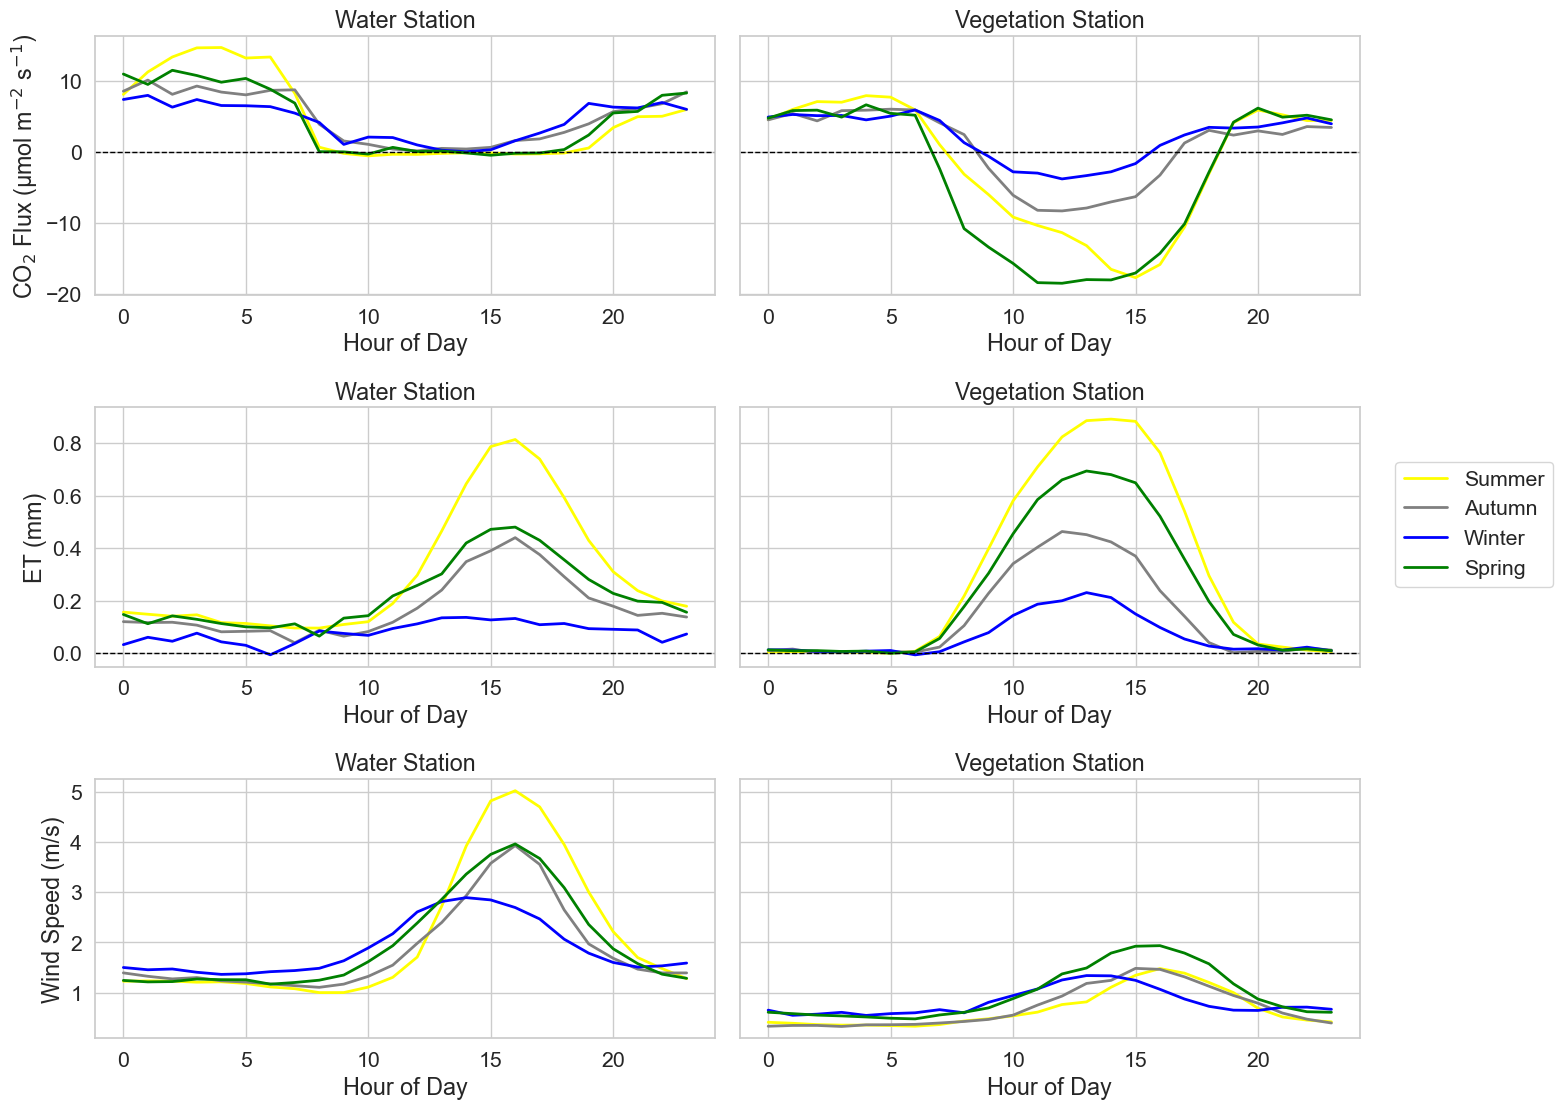

In [ ]:
def plot_seasonal_trends_two_subplots_all(parameters, labels, show_zero_line=False, path_to_save=None):
    # Define season ranges and colors
    seasons = {
        'summer': {'months': range(6, 9), 'color': 'yellow'},
        'autumn': {'months': range(9, 12), 'color': 'gray'},
        'winter': {'months': [12] + list(range(1, 3)), 'color': 'blue'},
        'spring': {'months': [3, 4, 5], 'color': 'green'}
    }

    # Create a figure with an N x 2 grid layout where N is the number of parameters
    fig, axs = plt.subplots(nrows=len(parameters), ncols=2, figsize=(14, 4 * len(parameters)), sharey='row')
    # fig.suptitle('Seasonal Trends for Multiple Parameters', fontsize=16)

    # Define the range of hours for x-axis
    hours = range(24)

    # Iterate over each parameter to plot on separate rows
    for row, parameter in enumerate(parameters):
        label = labels.get(parameter, parameter)

        # Iterate over each season to plot the data
        for season, data in seasons.items():
            # Filter data for the current season
            season_data_water = water_df[water_df.index.month.isin(data['months'])]
            season_data_veg = veg_df[veg_df.index.month.isin(data['months'])]

            # Group data by hour and compute median and standard deviation
            water_grouped_mean = season_data_water.groupby(season_data_water.index.hour)[parameter].mean()
            water_grouped_std = season_data_water.groupby(season_data_water.index.hour)[parameter].std()

            veg_grouped_mean = season_data_veg.groupby(season_data_veg.index.hour)[parameter].mean()
            veg_grouped_std = season_data_veg.groupby(season_data_veg.index.hour)[parameter].std()

            # Plot lines for water and vegetation stations
            axs[row, 0].plot(hours, water_grouped_mean, label=f'{season.capitalize()}', color=data['color'], lw=2)
            axs[row, 1].plot(hours, veg_grouped_mean, label=f'{season.capitalize()}', color=data['color'], lw=2)

        # Customize axes for water station
        axs[row, 0].set_title('Water Station')
        axs[row, 0].set_xlabel('Hour of Day')
        axs[row, 0].set_ylabel(label)

        # Customize axes for vegetation station
        axs[row, 1].set_title('Vegetation Station')
        axs[row, 1].set_xlabel('Hour of Day')
        # axs[row, 1].set_ylabel(label)

        # Set the same y-limits for both stations for consistency
        y_min = min(axs[row, 0].get_ylim()[0], axs[row, 1].get_ylim()[0])
        y_max = max(axs[row, 0].get_ylim()[1], axs[row, 1].get_ylim()[1])
        axs[row, 0].set_ylim(y_min, y_max)
        axs[row, 1].set_ylim(y_min, y_max)

        # Add zero line if specified
        if show_zero_line:
            axs[row, 0].axhline(0, color='black', linestyle='--', linewidth=1)
            axs[row, 1].axhline(0, color='black', linestyle='--', linewidth=1)

    # Add legend beside the plots
    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))
    
    # Adjust layout and spacing
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Save figure if a path is provided
    if path_to_save:
        fig.savefig(path_to_save, dpi=300, bbox_inches='tight')

    plt.show()

# Usage
selected_parameters = ['co2_flux', 'ET', 'ws']
selected_labels = {param: y_labels[param] for param in selected_parameters if param in y_labels}
filepath = "figures/Figure-S2.png"
plot_seasonal_trends_two_subplots_all(selected_parameters, selected_labels, show_zero_line=True, path_to_save=filepath)

### Figure 5

In [ ]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress
#see txt file with gee js script how the index was made

# ============================================================
# USER SETTINGS
# ============================================================

# Environment-variable overrides make the same script easy to test elsewhere,
# while these Windows paths remain the defaults for your computer.
VI_FILE = os.environ.get(
    "VI_FILE",
    r"C:\hula_data\data\Water_Station_TS_Raw_NDVI_2Month_Centered.csv",
)
WATER_FILLED_FILE = os.environ.get(
    "WATER_FILLED_FILE",
    r"C:\hula_data\data\water-gapfilled-MDS_only.csv",
)
FIGURE_OUTPUT_DIR = os.environ.get(
    "FIGURE_OUTPUT_DIR",
    r"C:\hula_data\data\figures\water_indices",
)

# The script automatically uses all numeric index columns except the metadata
# columns listed below. Set INDEX_COLUMNS to a list to choose them manually,
# e.g. INDEX_COLUMNS = ["NDVI", "GCC", "NDCI"].
INDEX_COLUMNS = None

EXCLUDE_NUMERIC_COLUMNS = {
    "year",
    "month",
    "day_of_year",
    "system:time_start",
    "scene_cloud_percent",
    "NDVI_WINDOW_DAYS",
}

# The supplied CSV contains raw, non-interpolated indices. Apply the same
# centered two-month smoothing to NDVI and every other selected index.
PRE_SMOOTHED_INDEX_COLUMNS = set()

START_DATE = "2021-05-01"
ROLLING_WINDOW_DAYS = 60
VI_MIN_OBSERVATIONS_IN_WINDOW = 3
CO2_MIN_DAYS_IN_WINDOW = 30

# Statistics calculated for the output table. Options: "plotted" or "raw".
# "plotted" compares the index and CO2 series actually drawn in the figure.
FIGURE_STATISTICS_MODE = "plotted"

FIGURE_PREFIX = "Figure-04"
METRICS_FILE_NAME = "Water_indices_CO2_statistics.csv"
DPI = 300
SHOW_FIGURES = False

# Optional fixed y-axis limits. Unlisted indices use automatic limits.
INDEX_YLIMS = {
    "NDVI": (-0.8, 0.0),
}

INDEX_LABELS = {
    "GCC": "GCC",
    "NDVI": "NDVI (2-month centered)",
    "NDVI_RAW_ORIGINAL": "NDVI (raw original)",
    "NDTI": "NDTI",
    "NDPI": "NDPI",
    "FAI": "FAI",
    "NDCI": "NDCI",
    "KINNERET_2B": "Kinneret 2-band index",
    "KINNERET_3B": "Kinneret 3-band index",
}


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def safe_filename(text):
    """Return a filesystem-safe filename component."""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text)).strip("_")


def centered_time_mean(series, days, min_observations):
    """Centered time-based rolling mean for an irregular DatetimeIndex."""
    return series.rolling(
        window=f"{days}D",
        center=True,
        min_periods=min_observations,
    ).mean()


def calculate_regression_metrics(index_series, co2_series):
    """
    Regress daily CO2 flux on an index and return r, R2 and regression RMSE.

    RMSE is calculated between observed CO2 flux and CO2 flux predicted by the
    fitted linear regression, so its units are micromol CO2 m-2 s-1.
    """
    merged = pd.concat(
        [index_series.rename("index"), co2_series.rename("co2_flux")],
        axis=1,
        join="inner",
    ).dropna()

    n = len(merged)
    if n < 3 or merged["index"].nunique() < 2:
        return {
            "n": n,
            "r": np.nan,
            "R2": np.nan,
            "RMSE": np.nan,
            "p_value": np.nan,
            "slope": np.nan,
            "intercept": np.nan,
        }

    result = linregress(merged["index"], merged["co2_flux"])
    predicted = result.intercept + result.slope * merged["index"]
    rmse = np.sqrt(np.mean((merged["co2_flux"] - predicted) ** 2))

    return {
        "n": n,
        "r": result.rvalue,
        "R2": result.rvalue ** 2,
        "RMSE": rmse,
        "p_value": result.pvalue,
        "slope": result.slope,
        "intercept": result.intercept,
    }


def add_season_background(ax, start_date, end_date):
    """Shade complete summer and winter periods across the plotting range."""
    daily_index = pd.date_range(start_date.normalize(), end_date.normalize(), freq="D")
    months = daily_index.month
    summer_mask = np.asarray((months >= 6) & (months <= 8))
    winter_mask = np.asarray((months == 12) | (months <= 2))

    for mask, color in ((summer_mask, "#FFF9C4"), (winter_mask, "#E3F2FD")):
        padded = np.concatenate(([False], mask, [False])).astype(int)
        boundaries = np.flatnonzero(np.diff(padded))
        for start, end in zip(boundaries[::2], boundaries[1::2]):
            left = daily_index[start]
            right = daily_index[end - 1] + pd.Timedelta(days=1)
            ax.axvspan(
                left,
                right,
                facecolor=color,
                alpha=0.30,
                edgecolor="none",
                zorder=0,
            )


def metric_legend_label(period_name, metrics):
    if np.isnan(metrics["r"]):
        return f"{period_name} (insufficient matched data; n={metrics['n']})"
    return (
        f"{period_name} "
        f"($r$={metrics['r']:.2f}, $R^2$={metrics['R2']:.2f}, "
        f"RMSE={metrics['RMSE']:.2f}, n={metrics['n']})"
    )


# ============================================================
# 1. LOAD THE SATELLITE-INDEX FILE
# ============================================================

vi_df = pd.read_csv(VI_FILE)

if "date" in vi_df.columns:
    vi_df["date"] = pd.to_datetime(vi_df["date"], errors="coerce")
    vi_df = vi_df.dropna(subset=["date"]).set_index("date")
else:
    # Fallback for a CSV whose first column is an unnamed date index.
    first_column = vi_df.columns[0]
    parsed_dates = pd.to_datetime(vi_df[first_column], errors="coerce")
    if parsed_dates.notna().sum() == 0:
        raise ValueError("No usable 'date' column was found in the vegetation-index CSV.")
    vi_df[first_column] = parsed_dates
    vi_df = vi_df.dropna(subset=[first_column]).set_index(first_column)

vi_df.index = pd.DatetimeIndex(vi_df.index).normalize()
vi_df = vi_df.sort_index()

# If more than one Sentinel-2 scene occurs on the same date, use its daily mean.
numeric_columns = vi_df.select_dtypes(include=[np.number]).columns.tolist()
vi_daily = vi_df[numeric_columns].groupby(level=0).mean()

if INDEX_COLUMNS is None:
    index_columns = [
        column
        for column in numeric_columns
        if column not in EXCLUDE_NUMERIC_COLUMNS
    ]
else:
    missing_indices = [column for column in INDEX_COLUMNS if column not in vi_daily.columns]
    if missing_indices:
        raise ValueError(f"Index columns not found in the VI file: {missing_indices}")
    index_columns = list(INDEX_COLUMNS)

if not index_columns:
    raise ValueError("No index columns were selected from the vegetation-index CSV.")


# ============================================================
# 2. LOAD GAP-FILLED WATER CO2-FLUX DATA
# ============================================================

df_water = pd.read_csv(WATER_FILLED_FILE, parse_dates=["time"])
if "time" not in df_water.columns:
    raise ValueError("The water file does not contain a 'time' column.")

df_water = df_water.dropna(subset=["time"]).set_index("time").sort_index()

if "co2_flux_filled" in df_water.columns:
    if "co2_flux" in df_water.columns:
        df_water["co2_flux_obs"] = df_water["co2_flux"]
    df_water["co2_flux"] = df_water["co2_flux_filled"]

if "co2_flux" not in df_water.columns:
    raise ValueError("Neither 'co2_flux' nor 'co2_flux_filled' was found in the water file.")

restore_map = {"TA_": "Ta", "SW_IN": "SWTop"}
df_water.rename(
    columns={
        old: new
        for old, new in restore_map.items()
        if old in df_water.columns and new not in df_water.columns
    },
    inplace=True,
)


# ============================================================
# 3. DAY/NIGHT CLASSIFICATION
# ============================================================

if "day_night" not in df_water.columns:
    if "Rn" in df_water.columns:
        df_water["day_night"] = np.where(df_water["Rn"] > 0, "day", "night")
    else:
        sw_col = (
            "SWTop"
            if "SWTop" in df_water.columns
            else ("SWBottom" if "SWBottom" in df_water.columns else None)
        )
        if sw_col is None:
            raise ValueError(
                "No 'day_night' column and no Rn/SWTop/SWBottom column is available."
            )
        df_water["day_night"] = np.where(df_water[sw_col] > 10, "day", "night")

df_water["day_night"] = (
    df_water["day_night"].astype(str).str.strip().str.lower()
)


# ============================================================
# 4. DAILY DAYTIME / NIGHTTIME MEAN CO2 FLUX
# ============================================================

co2_day_raw = (
    df_water.loc[df_water["day_night"] == "day", "co2_flux"]
    .resample("D")
    .mean()
)
co2_night_raw = (
    df_water.loc[df_water["day_night"] == "night", "co2_flux"]
    .resample("D")
    .mean()
)

if co2_day_raw.dropna().empty or co2_night_raw.dropna().empty:
    raise ValueError("No valid daily daytime or nighttime CO2 values were produced.")


# ============================================================
# 5. COMMON DATE RANGE AND 60-DAY CO2 SERIES
# ============================================================

requested_start = pd.Timestamp(START_DATE)
plot_start = max(requested_start, vi_daily.index.min(), df_water.index.min().normalize())
plot_end = min(vi_daily.index.max(), df_water.index.max().normalize())

if plot_start > plot_end:
    raise ValueError("The vegetation-index and water CO2 files do not overlap in time.")

vi_plot = vi_daily.loc[plot_start:plot_end, index_columns].copy()
co2_day_raw = co2_day_raw.loc[plot_start:plot_end]
co2_night_raw = co2_night_raw.loc[plot_start:plot_end]

co2_day_plotted = centered_time_mean(
    co2_day_raw, ROLLING_WINDOW_DAYS, CO2_MIN_DAYS_IN_WINDOW
)
co2_night_plotted = centered_time_mean(
    co2_night_raw, ROLLING_WINDOW_DAYS, CO2_MIN_DAYS_IN_WINDOW
)


# ============================================================
# 6. MAKE ONE FIGURE PER INDEX AND CALCULATE STATISTICS
# ============================================================

output_dir = Path(FIGURE_OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

metrics_rows = []
created_figures = []

for index_name in index_columns:
    index_raw = vi_plot[index_name].dropna()
    if index_raw.empty:
        print(f"Skipping {index_name}: no valid values in the common date range.")
        continue

    if index_name in PRE_SMOOTHED_INDEX_COLUMNS:
        index_plotted = index_raw.copy()
    else:
        index_plotted = centered_time_mean(
            index_raw,
            ROLLING_WINDOW_DAYS,
            VI_MIN_OBSERVATIONS_IN_WINDOW,
        )

    series_by_mode = {
        "raw": (index_raw, co2_day_raw, co2_night_raw),
        "plotted": (index_plotted, co2_day_plotted, co2_night_plotted),
    }

    all_metrics = {}
    for mode, (index_series, day_series, night_series) in series_by_mode.items():
        for period, co2_series in (("day", day_series), ("night", night_series)):
            metrics = calculate_regression_metrics(index_series, co2_series)
            all_metrics[(mode, period)] = metrics
            metrics_rows.append(
                {
                    "index": index_name,
                    "series": mode,
                    "period": period,
                    **metrics,
                }
            )

    day_metrics = all_metrics[(FIGURE_STATISTICS_MODE, "day")]
    night_metrics = all_metrics[(FIGURE_STATISTICS_MODE, "night")]

    print(f"\n{index_name} — {FIGURE_STATISTICS_MODE} series")
    print(
        f"  Daytime:   r={day_metrics['r']:.3f}, "
        f"R2={day_metrics['R2']:.3f}, RMSE={day_metrics['RMSE']:.3f}, "
        f"p={day_metrics['p_value']:.2e}, n={day_metrics['n']}"
    )
    print(
        f"  Nighttime: r={night_metrics['r']:.3f}, "
        f"R2={night_metrics['R2']:.3f}, RMSE={night_metrics['RMSE']:.3f}, "
        f"p={night_metrics['p_value']:.2e}, n={night_metrics['n']}"
    )

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(13.04, 6.20),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 2], "hspace": 0.16},
    )

    add_season_background(ax1, plot_start, plot_end)
    add_season_background(ax2, plot_start, plot_end)

    # Panel A: current satellite index.
    ax1.plot(
        index_plotted.index,
        index_plotted,
        color="#2E7D32",
        label=INDEX_LABELS.get(index_name, index_name),
        linewidth=2,
        zorder=4,
    )
    # Keep the axis label compact; the longer description remains in the code
    # and can be used in a caption if desired.
    ax1.set_ylabel(index_name, fontsize=14)
    if index_name in INDEX_YLIMS:
        ax1.set_ylim(*INDEX_YLIMS[index_name])
    ax1.tick_params(axis="y", labelsize=12)

    # Panel B: smoothed CO2 flux. Statistics are written to the CSV table,
    # while the figure legend contains only the series names.
    ax2.plot(
        co2_night_plotted.index,
        co2_night_plotted,
        color="#1A237E",
        label="Nighttime",
        linewidth=2,
        zorder=5,
    )
    ax2.plot(
        co2_day_plotted.index,
        co2_day_plotted,
        color="#FF6F00",
        label="Daytime",
        linewidth=2,
        zorder=6,
    )

    ax2.set_ylabel(r"CO$_2$ flux ($\mu$mol m$^{-2}$ s$^{-1}$)", fontsize=14)
    ax2.tick_params(axis="y", labelsize=12)

    ax2.axhline(y=0, color="white", linewidth=3.4, linestyle="-", zorder=8)
    ax2.axhline(
        y=0,
        color="#000000",
        linewidth=2.0,
        linestyle="--",
        dashes=(5, 3),
        zorder=9,
    )

    ax2.legend(
        loc="upper right",
        bbox_to_anchor=(0.995, 1.08),
        frameon=True,
        facecolor="white",
        edgecolor="none",
        framealpha=0.90,
        fontsize=9.5,
    )

    major_locator = mdates.MonthLocator(bymonth=(3, 6, 9, 12))
    ax2.xaxis.set_major_locator(major_locator)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax2.xaxis.set_minor_locator(mdates.MonthLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0, ha="center")

    ax1.text(
        0.02,
        0.90,
        "a",
        transform=ax1.transAxes,
        fontsize=16,
        fontweight="bold",
        va="center",
    )
    ax2.text(
        0.02,
        0.90,
        "b",
        transform=ax2.transAxes,
        fontsize=16,
        fontweight="bold",
        va="center",
    )

    for ax in (ax1, ax2):
        ax.grid(
            True,
            linestyle=":",
            color="#BDBDBD",
            linewidth=0.8,
            alpha=0.60,
            zorder=1,
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#BDBDBD")
        ax.spines["bottom"].set_color("#BDBDBD")
        ax.tick_params(which="both", direction="out", length=6, width=1)
        ax.tick_params(which="minor", length=3)

    # Keep the upper x-axis line visible, but remove its tick marks and labels.
    ax1.spines["bottom"].set_visible(True)
    ax1.spines["bottom"].set_color("#BDBDBD")
    ax1.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    ax2.set_xlim(plot_start, plot_end)

    figure_name = f"{FIGURE_PREFIX}_{safe_filename(index_name)}.png"
    output_path = output_dir / figure_name
    fig.subplots_adjust(left=0.105, right=0.985, bottom=0.125, top=0.975, hspace=0.16)
    fig.savefig(output_path, dpi=DPI, bbox_inches="tight", facecolor="white")
    created_figures.append(output_path)
    print(f"  Figure saved to: {output_path}")

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# 7. SAVE THE COMPLETE STATISTICS TABLE
# ============================================================

if not metrics_rows:
    raise ValueError("No index figures or statistics could be produced.")

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df[
    [
        "index",
        "series",
        "period",
        "n",
        "r",
        "R2",
        "RMSE",
        "p_value",
        "slope",
        "intercept",
    ]
]

metrics_path = output_dir / METRICS_FILE_NAME
metrics_df.to_csv(metrics_path, index=False, float_format="%.6f")

# Show a compact, notebook-friendly results table. The full table, including
# raw and plotted series plus regression coefficients, remains in the CSV.
notebook_metrics_df = metrics_df.loc[
    metrics_df["series"] == FIGURE_STATISTICS_MODE,
    ["index", "period", "n", "r", "R2", "RMSE"],
].copy()
notebook_metrics_df[["r", "R2", "RMSE"]] = notebook_metrics_df[
    ["r", "R2", "RMSE"]
].round(3)

print("\nIndex–CO2 statistics table:")
try:
    from IPython.display import display

    display(notebook_metrics_df)
except ImportError:
    print(notebook_metrics_df.to_string(index=False))

print("\nCompleted successfully.")
print(f"Indices processed: {len(created_figures)}")
print(f"Statistics saved to: {metrics_path}")
print(f"Figures saved in: {output_dir}")



GCC — plotted series
  Daytime:   r=-0.070, R2=0.005, RMSE=0.662, p=3.74e-01, n=161
  Nighttime: r=0.095, R2=0.009, RMSE=1.568, p=2.29e-01, n=161
  Figure saved to: C:\hula_data\data\figures\water_indices\Figure-04_GCC.png

NDVI — plotted series
  Daytime:   r=0.506, R2=0.256, RMSE=0.572, p=7.34e-12, n=161
  Nighttime: r=-0.322, R2=0.104, RMSE=1.492, p=3.12e-05, n=161
  Figure saved to: C:\hula_data\data\figures\water_indices\Figure-04_NDVI.png

NDVI_RAW_ORIGINAL — plotted series
  Daytime:   r=0.430, R2=0.185, RMSE=0.599, p=1.28e-08, n=161
  Nighttime: r=-0.269, R2=0.072, RMSE=1.517, p=5.55e-04, n=161
  Figure saved to: C:\hula_data\data\figures\water_indices\Figure-04_NDVI_RAW_ORIGINAL.png

NDTI — plotted series
  Daytime:   r=-0.099, R2=0.010, RMSE=0.660, p=2.13e-01, n=161
  Nighttime: r=-0.153, R2=0.023, RMSE=1.557, p=5.34e-02, n=161
  Figure saved to: C:\hula_data\data\figures\water_indices\Figure-04_NDTI.png

NDPI — plotted series
  Daytime:   r=-0.452, R2=0.204, RMSE=0.592, p=1

,index,period,n,r,R2,RMSE
2,GCC,day,161,-0.070,0.005,0.662
3,GCC,night,161,0.095,0.009,1.568
6,NDVI,day,161,0.506,0.256,0.572
7,NDVI,night,161,-0.322,0.104,1.492
10,NDVI_RAW_ORIGINAL,day,161,0.430,0.185,0.599
11,NDVI_RAW_ORIGINAL,night,161,-0.269,0.072,1.517
14,NDTI,day,161,-0.099,0.010,0.660
15,NDTI,night,161,-0.153,0.023,1.557
18,NDPI,day,161,-0.452,0.204,0.592
19,NDPI,night,161,0.169,0.029,1.553



Completed successfully.
Indices processed: 9
Statistics saved to: C:\hula_data\data\figures\water_indices\Water_indices_CO2_statistics.csv
Figures saved in: C:\hula_data\data\figures\water_indices


### Figure S3


In [ ]:
# Define the output paths for the processed vegetation and water station data
veg_path = r"C:\hula_data\data\vegetation-gapfilled-MDS_only.csv"
water_path = r"C:\hula_data\data\water-gapfilled-MDS_only.csv"

# Reload the data to demonstrate clean loading
veg_df = pd.read_csv(veg_path, index_col='time', parse_dates=['time'])
water_df = pd.read_csv(water_path, index_col='time', parse_dates=['time'])

# Reload the data to demonstrate clean loading
veg_df   = pd.read_csv(veg_path,   index_col="time", parse_dates=["time"])
water_df = pd.read_csv(water_path, index_col="time", parse_dates=["time"])

# 1) Use the merged filled series for plotting, but keep original as backup
for df in (veg_df, water_df):
    if "co2_flux_filled" in df.columns:
        df["co2_flux_obs"] = df.get("co2_flux")         # preserve original observations
        df["co2_flux"]     = df["co2_flux_filled"]      # alias filled → co2_flux used by old plots

# 2) Restore original column names (edit SWTop if your incoming SW was different)
RESTORE_MAP = {
    "TA_":   "Ta",
    "SW_IN": "SWTop",   # change to "SWBottom" if that was your original incoming SW
}
for df in (veg_df, water_df):
    df.rename(columns=RESTORE_MAP, inplace=True)

# 3) (Optional) Clean up internal/helper columns so the schema matches your old figures
INTERNAL_COLS = [
    "NEE_work", "isday",
    "co2_flux_MDS", "co2_flux_MDS_QC",
    "co2_flux_filled", "co2_flux_fill_flag"
]
for df in (veg_df, water_df):
    drop_cols = [c for c in INTERNAL_COLS if c in df.columns]
    if drop_cols:
        df.drop(columns=drop_cols, inplace=True)

# convert (z-d)/L values not between -1 to 1 to NaN
# water_df['(z-d)/L'] = water_df['(z-d)/L'].mask((water_df['(z-d)/L'] < -1) | (water_df['(z-d)/L'] > 1))
water_df = water_df[(water_df['(z-d)/L'] >= -1) & (water_df['(z-d)/L'] <= 1)]

C:\Users\yaron\AppData\Local\Temp\ipykernel_12768\3169226572.py:112: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yaron\AppData\Local\Temp\ipykernel_12768\3169226572.py:112: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yaron\AppData\Local\Temp\ipykernel_12768\3169226572.py:116: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
C:\Users\yaron\AppData\Local\Temp\ipykernel_12768\3169226572.py:116: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
c:\Users\yaron\miniforge3\envs\geo_new\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yaron\miniforge3\envs\geo_new\Lib\site-packages\IPython\core\pyl

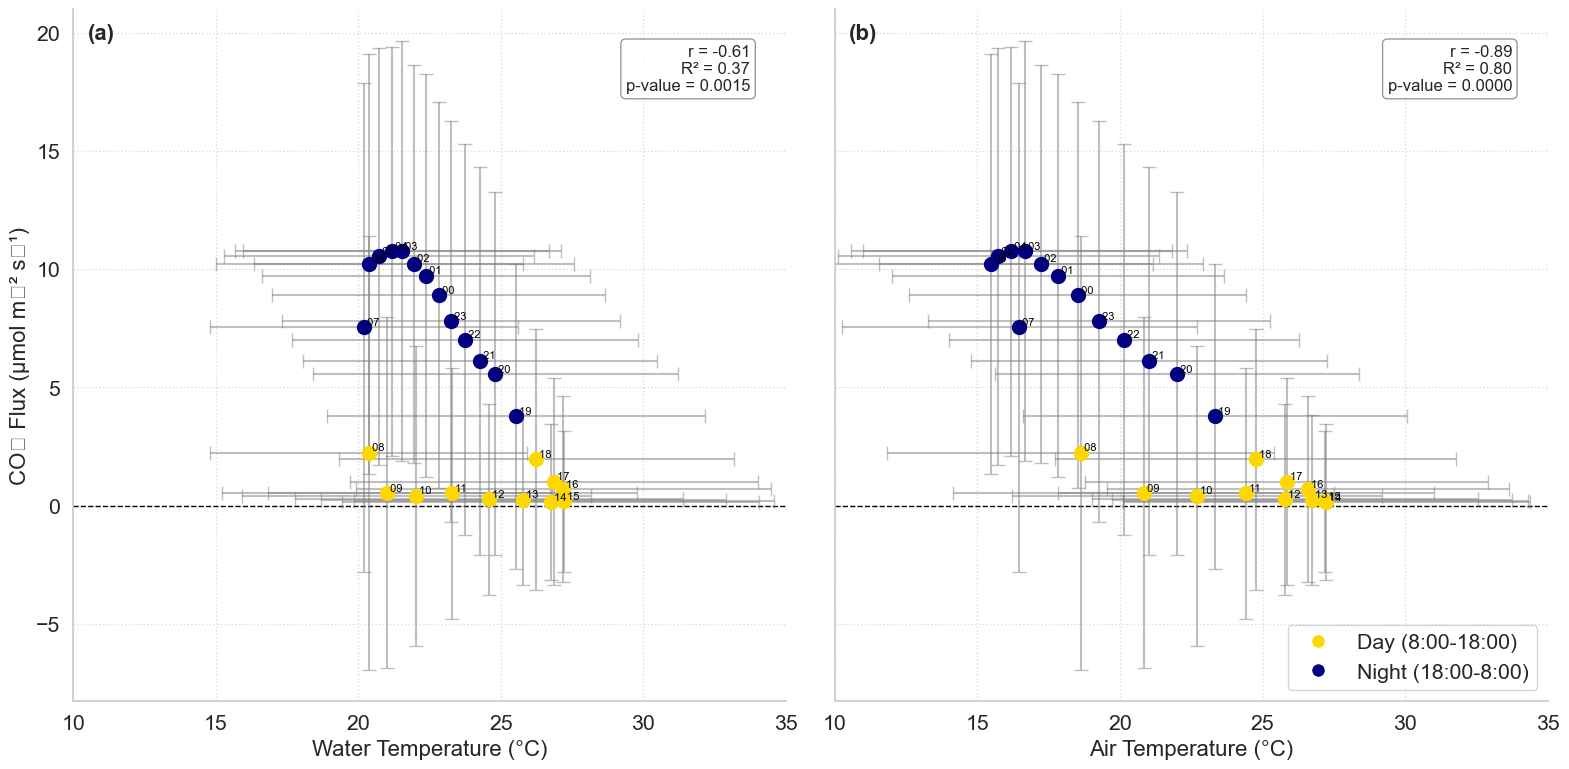

In [ ]:
def get_color(hour):
    """Return 'gold' during daytime (8-18) and 'navy' for night."""
    return 'gold' if 8 <= hour <= 18 else 'navy'

# ---------------------------
# Water Temperature vs CO₂ Flux
# ---------------------------
# Group data by the hour
grouped = water_df.groupby(water_df.index.hour)
tw_means = grouped['Tw'].mean()
tw_stds  = grouped['Tw'].std()
co2_means = grouped['co2_flux'].mean()
co2_stds  = grouped['co2_flux'].std()

# Compute Pearson correlation
df_water = pd.DataFrame({'Tw': tw_means, 'co2_flux': co2_means})
r_water, p_water = pearsonr(df_water['Tw'], df_water['co2_flux'])

# ---------------------------
# Air Temperature vs CO₂ Flux
# ---------------------------
# Compute grouped statistics for air temperature
ta_means = grouped['Ta'].mean()
ta_stds  = grouped['Ta'].std()

# Compute Pearson correlation
df_air = pd.DataFrame({'Ta': ta_means, 'co2_flux': co2_means})
r_air, p_air = pearsonr(df_air['Ta'], df_air['co2_flux'])

# ---------------------------
# Create subplots
# ---------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Common styling for both panels
for ax in (ax1, ax2):
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ---------------------------
# Plot (a): Water Temperature vs CO₂ Flux
# ---------------------------
for hour in range(24):
    if hour not in tw_means.index:
        continue
    color = get_color(hour)
    x_val = tw_means.loc[hour]
    y_val = co2_means.loc[hour]
    x_err = tw_stds.loc[hour] if pd.notnull(tw_stds.loc[hour]) else 0
    y_err = co2_stds.loc[hour] if pd.notnull(co2_stds.loc[hour]) else 0

    # Plot error bars and marker
    ax1.errorbar(x_val, y_val, xerr=x_err, yerr=y_err,
                 fmt='none', ecolor='gray', alpha=0.5, capsize=5)
    ax1.scatter(x_val, y_val, s=100, color=color, zorder=3)
    # Plot hour label with higher zorder (in front of the marker)
    ax1.text(x_val, y_val, f' {hour:02d}', fontsize=8,
             verticalalignment='bottom', color='black', zorder=4)

ax1.set_xlabel('Water Temperature (°C)', fontsize=16)
ax1.set_ylabel('CO₂ Flux (μmol m⁻² s⁻¹)', fontsize=16)
ax1.set_xlim(10, 35)
stats_text_water = f'r = {r_water:.2f}\nR² = {r_water**2:.2f}\np-value = {p_water:.4f}'
ax1.text(0.95, 0.95, stats_text_water, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.8))
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, size=16,
         weight='bold', verticalalignment='top', zorder=4)

# ---------------------------
# Plot (b): Air Temperature vs CO₂ Flux
# ---------------------------
for hour in range(24):
    if hour not in ta_means.index:
        continue
    color = get_color(hour)
    x_val = ta_means.loc[hour]
    y_val = co2_means.loc[hour]
    x_err = ta_stds.loc[hour] if pd.notnull(ta_stds.loc[hour]) else 0
    y_err = co2_stds.loc[hour] if pd.notnull(co2_stds.loc[hour]) else 0

    ax2.errorbar(x_val, y_val, xerr=x_err, yerr=y_err,
                 fmt='none', ecolor='gray', alpha=0.5, capsize=5)
    ax2.scatter(x_val, y_val, s=100, color=color, zorder=3)
    ax2.text(x_val, y_val, f' {hour:02d}', fontsize=8,
             verticalalignment='bottom', color='black', zorder=4)

ax2.set_xlabel('Air Temperature (°C)', fontsize=16)
ax2.set_xlim(10, 35)
stats_text_air = f'r = {r_air:.2f}\nR² = {r_air**2:.2f}\np-value = {p_air:.4f}'
ax2.text(0.95, 0.95, stats_text_air, transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.8))
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, size=16,
         weight='bold', verticalalignment='top', zorder=4)

# ---------------------------
# Create a custom legend
# ---------------------------
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Day (8:00-18:00)',
           markerfacecolor='gold', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Night (18:00-8:00)',
           markerfacecolor='navy', markersize=10)
]
ax2.legend(handles=legend_elements, loc='lower right')


plt.tight_layout()

# Save the figure
save_path = r"C:\hula_data\data\figures\Figure-S3.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

Same with standard error bars, not standard deviation

### Figure 5

In [ ]:
def get_day_night_color(hour):
    """
    Determines color based on hour of the day to differentiate day and night periods.

    Parameters:
        hour (int): Hour of the day (0-23).

    Returns:
        str: 'gold' for daytime hours (8:00-18:00), 'navy' for nighttime hours.
    """
    day_start_hour = 8
    day_end_hour = 18
    return 'gold' if day_start_hour <= hour <= day_end_hour else 'navy'

<>:96: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:96: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\yaron\AppData\Local\Temp\ipykernel_12768\4039117431.py:96: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax2_fig5.set_xlabel('$\mathit{T}_{Water} - \mathit{T}_{Air}$ (°C)', fontsize=16)



Generating Figure 5: Stability and Delta Temperature vs. CO₂ Flux...
Figure 5 saved to: C:/hula_data/data/figures/water_indices/Figure-05.png


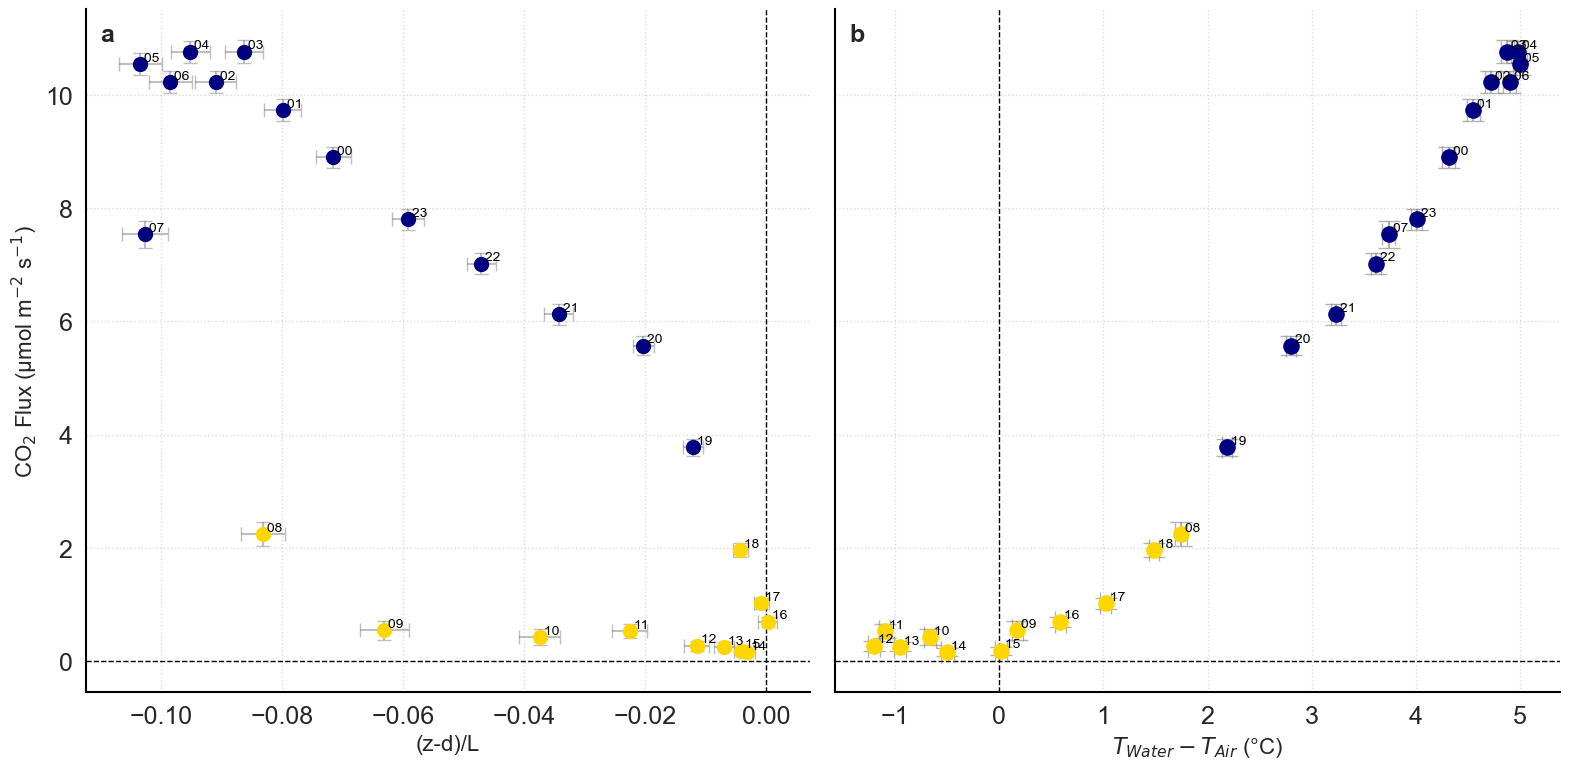

In [ ]:
# ------------------------------------------------------------------------------
#         10. Figure 5: Stability and Delta Temperature vs. CO₂ Flux
# ------------------------------------------------------------------------------
# Figure 5 examines the relationship of CO₂ flux with atmospheric stability ((z-d)/L) and
# temperature difference (dt = Tw - Ta), using hourly means and standard errors,
# colored by day and night periods. It has two panels: (a) Stability vs CO₂ Flux, and (b) dt vs CO₂ Flux.

print("\nGenerating Figure 5: Stability and Delta Temperature vs. CO₂ Flux...")

# Reuse the get_day_night_color function defined in Figure S4 section.

# Group water data by hour of the day for hourly statistics.
hourly_groups_fig5 = water_df.groupby(water_df.index.hour)

# Calculate hourly means and standard errors for stability, dt, and CO₂ flux.
hourly_mean_dt_fig5   = hourly_groups_fig5['dt'].mean()
hourly_se_dt_fig5     = hourly_groups_fig5['dt'].sem()
hourly_mean_stab_fig5 = hourly_groups_fig5['(z-d)/L'].mean()
hourly_se_stab_fig5   = hourly_groups_fig5['(z-d)/L'].sem()
hourly_mean_co2_flux_fig5  = hourly_groups_fig5['co2_flux'].mean()
hourly_se_co2_flux_fig5    = hourly_groups_fig5['co2_flux'].sem()

# Calculate Pearson correlation for Stability vs CO₂ Flux.
df_stab_corr_fig5 = pd.DataFrame({'(z-d)/L': hourly_mean_stab_fig5, 'co2_flux': hourly_mean_co2_flux_fig5})
r_stab_fig5, p_stab_fig5 = pearsonr(df_stab_corr_fig5['(z-d)/L'].dropna(), df_stab_corr_fig5['co2_flux'].dropna())

# Calculate Pearson correlation for dt vs CO₂ Flux.
df_dt_corr_fig5 = pd.DataFrame({'dt': hourly_mean_dt_fig5, 'co2_flux': hourly_mean_co2_flux_fig5})
r_dt_fig5, p_dt_fig5 = pearsonr(df_dt_corr_fig5['dt'].dropna(), df_dt_corr_fig5['co2_flux'].dropna())

# Create figure and subplots (1 row, 2 columns) for Figure 5.
fig_fig5, (ax1_fig5, ax2_fig5) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Apply common styling to both subplots.
for ax in (ax1_fig5, ax2_fig5):
    ax.grid(True, linestyle=':', alpha=0.7) # Dotted grid
    ax.axhline(0, color='black', lw=1, ls='--') # Dashed horizontal line at y=0
    ax.axvline(0, color='black', lw=1, ls='--') # Dashed vertical line at x=0
    ax.spines['top'].set_visible(False)    # Hide top spine
    ax.spines['right'].set_visible(False)  # Hide right spine
    # Make bottom and left spines more solid black
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=18)  # Increase tick label size

# ---------------------------
# Plot (a): Stability ((z-d)/L) vs CO₂ Flux
# ---------------------------
# Iterate through each hour to plot hourly means with error bars.
for hour in range(24):
    if hour not in hourly_mean_stab_fig5.index: # Skip hours with no data
        continue
    color = get_day_night_color(hour) # Determine color based on day/night
    x_val = hourly_mean_stab_fig5.loc[hour] # Hourly mean stability
    y_val = hourly_mean_co2_flux_fig5.loc[hour]  # Hourly mean CO₂ flux
    x_err = hourly_se_stab_fig5.loc[hour] if pd.notnull(hourly_se_stab_fig5.loc[hour]) else 0 # Stability standard error
    y_err = hourly_se_co2_flux_fig5.loc[hour] if pd.notnull(hourly_se_co2_flux_fig5.loc[hour]) else 0  # CO₂ flux standard error

    # Plot error bars and scatter points for each hour.
    ax1_fig5.errorbar(x_val, y_val, xerr=x_err, yerr=y_err,
                 fmt='none', ecolor='gray', alpha=0.5, capsize=5) # Error bars
    ax1_fig5.scatter(x_val, y_val, s=100, color=color, zorder=3) # Scatter points, colored by day/night
    ax1_fig5.text(x_val, y_val, f' {hour:02d}', fontsize=10,
             verticalalignment='bottom', color='black', zorder=4) # Hour labels

# Set labels, limits for panel (a).
ax1_fig5.set_xlabel('(z-d)/L', fontsize=16)
ax1_fig5.set_ylabel(y_labels['co2_flux'], fontsize=16) # Use predefined y-axis label
# ax1_fig5.set_xlim(-0.3, 0.1) # Set x-axis limits
ax1_fig5.text(0.02, 0.98, 'a', transform=ax1_fig5.transAxes, size=18,
         weight='bold', verticalalignment='top', zorder=4) # Panel label

# ---------------------------
# Plot (b): dt vs CO₂ Flux
# ---------------------------
# Repeat plotting process for dt vs CO₂ flux.
for hour in range(24):
    if hour not in hourly_mean_dt_fig5.index: # Skip hours with no data
        continue
    color = get_day_night_color(hour) # Determine color based on day/night
    x_val = hourly_mean_dt_fig5.loc[hour] # Hourly mean dt
    y_val = hourly_mean_co2_flux_fig5.loc[hour]  # Hourly mean CO₂ flux
    x_err = hourly_se_dt_fig5.loc[hour] if pd.notnull(hourly_se_dt_fig5.loc[hour]) else 0 # dt standard error
    y_err = hourly_se_co2_flux_fig5.loc[hour] if pd.notnull(hourly_se_co2_flux_fig5.loc[hour]) else 0  # CO₂ flux standard error

    # Plot error bars and scatter points for each hour.
    ax2_fig5.errorbar(x_val, y_val, xerr=x_err, yerr=y_err,
                 fmt='none', ecolor='gray', alpha=0.6, capsize=8) # Error bars
    ax2_fig5.scatter(x_val, y_val, s=120, color=color, zorder=3) # Scatter points, colored by day/night
    ax2_fig5.text(x_val, y_val, f' {hour:02d}', fontsize=10,
             verticalalignment='bottom', color='black', zorder=4) # Hour labels

# Set labels, title for panel (b).
ax2_fig5.set_xlabel('$\mathit{T}_{Water} - \mathit{T}_{Air}$ (°C)', fontsize=16)
ax2_fig5.text(0.02, 0.98, 'b', transform=ax2_fig5.transAxes, size=18,
         weight='bold', verticalalignment='top', zorder=4) # Panel label


plt.tight_layout() # Adjust layout

# Save Figure 5 to the output directory.
figure5_save_path = f"{FIGURE_OUTPUT_DIR}/Figure-05.png"
plt.savefig(figure5_save_path, dpi=400, bbox_inches='tight')
print(f"Figure 5 saved to: {figure5_save_path}")

plt.show() # Display Figure

### Figure 6


Generating Figure 6c: Water Cover vs. NEP...
Figure 6c saved to: figures/Figure-06.png


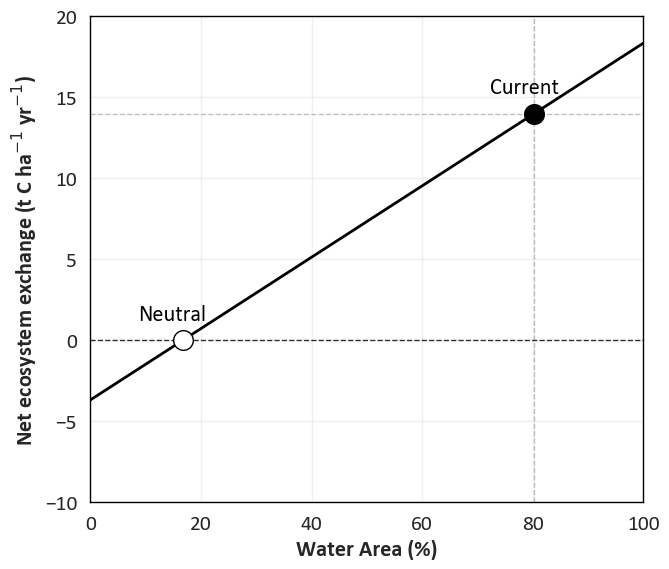

In [ ]:
# ------------------------------------------------------------------------------
#         11. Figure 6: Yearly CO₂ Flux and Water Table Depth Relationship
# ------------------------------------------------------------------------------
# Figure 6 explores the relationship between yearly CO₂ flux and effective water table depth,
# comparing our site's flux with a global relationship from Evans et al. (2021).
# It includes three panels: (a) Yearly flux vs. water table depth, (b) Day and night NEP vs. water table depth,
# and (c) Water cover vs. NEP, illustrating different aspects of ecosystem carbon dynamics.

print("\nGenerating Figure 6c: Water Cover vs. NEP...")

def calculate_yearly_flux(mean_flux):
    """
    Calculates yearly CO₂ flux in ton hectare⁻¹ year⁻¹ from mean CO₂ flux in µmol m⁻² s⁻¹.

    Parameters:
        mean_flux (float): Mean CO₂ flux in µmol m⁻² s⁻¹.

    Returns:
        float: Yearly CO₂ flux in ton hectare⁻¹ year⁻¹.
    """
    # Constants for unit conversion.
    sec_to_year = 60 * 60 * 24 * 365 # Seconds in a year
    molar_mass_co2 = 12.01 # g/mol (Molar mass of Carbon in CO2)
    micromol_to_mol = 1e-6 # Conversion from micromoles to moles
    mol_to_g = molar_mass_co2 # Conversion from moles of C to grams of C
    g_to_ton = 1e-6 # Conversion from grams to tons
    m2_to_hectare = 1e4 # Conversion from square meters to hectares

    # Conversion formula.
    yearly_flux_ton_per_hectare = (mean_flux *
                                   sec_to_year *
                                   micromol_to_mol *
                                   mol_to_g *
                                   g_to_ton *
                                   m2_to_hectare)

    return yearly_flux_ton_per_hectare

# Compute overall flux means from all measurements for weighted average calculation.
water_flux_fig6 = calculate_yearly_flux(water_df['co2_flux'].mean())
veg_flux_fig6 = calculate_yearly_flux(veg_df['co2_flux'].mean())
total_area_fig6 = 1.3 + 0.32
actual_weighted_flux_fig6 = (water_flux_fig6 * 1.3 + veg_flux_fig6 * 0.32) / total_area_fig6

# Define water cover percentages for subplot (c).
water_percentages_fig6 = np.linspace(0, 100, 1000)

def calculate_weighted_flux(w_flux, v_flux, veg_percentage):
    """
    Calculates weighted flux based on vegetation percentage (0-100).

    Parameters:
        w_flux (float): Yearly flux for water station.
        v_flux (float): Yearly flux for vegetation station.
        veg_percentage (float): Vegetation cover percentage (0-100).

    Returns:
        float: Weighted yearly flux.
    """
    water_percentage = 100 - veg_percentage
    return (w_flux * water_percentage + v_flux * veg_percentage) / 100

# Calculate flux curve for varying water cover percentages.
fluxes_fig6 = [calculate_weighted_flux(water_flux_fig6, veg_flux_fig6, 100 - wp) for wp in water_percentages_fig6]
actual_veg_percentage_fig6 = (0.32 / total_area_fig6) * 100 # Actual vegetation percentage
actual_water_percentage_fig6 = 100 - actual_veg_percentage_fig6 # Actual water percentage

# Create figure and a single subplot for Figure 6c.
# Set font for calibri if available
plt.rcParams['font.family'] = 'Calibri'
fig_fig6, ax3_fig6 = plt.subplots(1, 1, figsize=(7, 6))

# Subplot (c): Water cover vs. NEP
ax3_fig6.plot(water_percentages_fig6, fluxes_fig6, color='black', linewidth=2) # Weighted flux curve
ax3_fig6.scatter(actual_water_percentage_fig6, actual_weighted_flux_fig6, color='black', s=200, label='Current', zorder=5,) # Current site flux point
zero_flux_veg_percentage_fig6 = (0 - water_flux_fig6) / (veg_flux_fig6 - water_flux_fig6) * 100 # Veg % for zero flux
zero_flux_water_percentage_fig6 = 100 - zero_flux_veg_percentage_fig6 # Water % for zero flux
ax3_fig6.scatter(zero_flux_water_percentage_fig6, 0, color='white', s=200, label='Neutral', zorder=5, edgecolors='black',) # Zero flux point
ax3_fig6.axvline(actual_water_percentage_fig6, color='gray', linestyle='--', linewidth=1, alpha=0.5) # Current water cover line
ax3_fig6.axhline(actual_weighted_flux_fig6, color='gray', linestyle='--', linewidth=1, alpha=0.5) # Current flux line
ax3_fig6.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.8) # Zero flux line
ax3_fig6.set_xlabel('Water Area (%)', fontsize=16, fontweight='bold')
ax3_fig6.set_ylabel('Net ecosystem exchange (t C ha$^{-1}$ yr$^{-1}$)', fontsize=16, fontweight='bold')

# Format axis.
ax3_fig6.grid(True, alpha=0.3) # Light grid
ax3_fig6.set_xlim(0, 100) # X-axis limits
ax3_fig6.set_ylim(-10, 20) # Y-axis limits
for spine in ax3_fig6.spines.values(): # Customize spines
    spine.set_linewidth(1)
    spine.set_color('black')

# Add "Neutral" label near zero flux point.
ax3_fig6.text(zero_flux_water_percentage_fig6 - 8, 1, 'Neutral', fontsize=16, verticalalignment='bottom', color='black')
# Add "Current" label near current site point.
ax3_fig6.text(actual_water_percentage_fig6 - 8, actual_weighted_flux_fig6 + 1, 'Current', fontsize=16, verticalalignment='bottom', color='black')

plt.tight_layout() # Adjust layout

# Save Figure 6c to the output directory.
FIGURE_OUTPUT_DIR = r"C:\hula_data\data\figures"
figure6_save_path = f"{FIGURE_OUTPUT_DIR}/Figure-06.png"
plt.savefig(figure6_save_path, dpi=300, bbox_inches='tight')
print(f"Figure 6c saved to: {figure6_save_path}")

plt.show() # Display Figure 6c


### Figure 7


Generating Combined Figure: Water Table Depth Relationship and Literature Comparison...
Combined figure saved to: figures/Figure-07.png


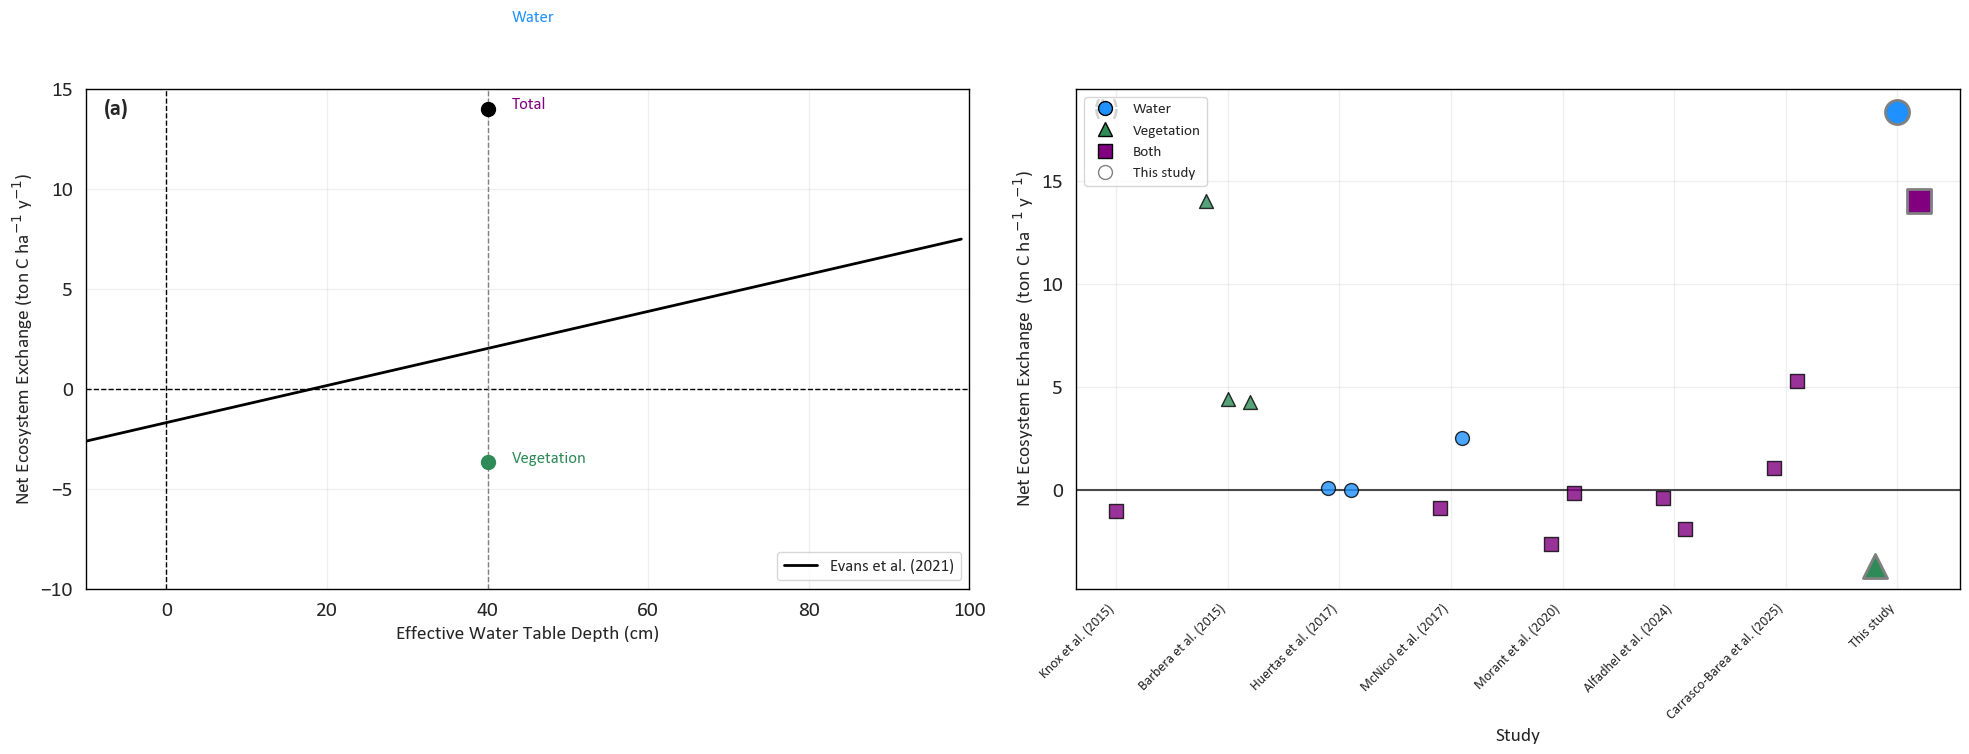

In [ ]:
# ------------------------------------------------------------------------------
#         Combined Figure: Water Table Depth Relationship and Literature Comparison
# ------------------------------------------------------------------------------

print("\nGenerating Combined Figure: Water Table Depth Relationship and Literature Comparison...")

def calculate_yearly_flux(mean_flux):
    """
    Calculates yearly CO₂ flux in ton hectare⁻¹ year⁻¹ from mean CO₂ flux in µmol m⁻² s⁻¹.
    """
    sec_to_year = 60 * 60 * 24 * 365
    molar_mass_co2 = 12.01
    micromol_to_mol = 1e-6
    mol_to_g = molar_mass_co2
    g_to_ton = 1e-6
    m2_to_hectare = 1e4
    
    yearly_flux_ton_per_hectare = (mean_flux *
                                   sec_to_year *
                                   micromol_to_mol *
                                   mol_to_g *
                                   g_to_ton *
                                   m2_to_hectare)
    return yearly_flux_ton_per_hectare

# Calculate yearly CO₂ flux for water and vegetation stations
mean_water_flux_fig6 = water_df['co2_flux'].mean()
mean_veg_flux_fig6 = veg_df['co2_flux'].mean()

yearly_water_flux_fig6 = calculate_yearly_flux(mean_water_flux_fig6)
yearly_veg_flux_fig6 = calculate_yearly_flux(mean_veg_flux_fig6)

# Calculate weighted average flux based on area ratio
water_flux_fig6 = calculate_yearly_flux(water_df['co2_flux'].mean())
veg_flux_fig6 = calculate_yearly_flux(veg_df['co2_flux'].mean())
actual_weighted_flux_fig6 = (water_flux_fig6 * 1.3 + veg_flux_fig6 * 0.32) / (1.3 + 0.32)

# Pre-compute expected NEP curve from Evans et al. (2021)
WTDe_fig6 = np.arange(-10, 100, 1)
nep_fig6 = 0.0927 * WTDe_fig6 - 1.69

# Literature data for comparison
literature_data = [
    # Huertas et al. (2017)
    {"Study": "Huertas et al. (2017)", "Flux": 0.101, "Type": "Water", "Note": "Wet season"},
    {"Study": "Huertas et al. (2017)", "Flux": 0.0082, "Type": "Water", "Note": "Dry season"},
    
    # Knox et al. (2015)
    {"Study": "Knox et al. (2015)", "Flux": -1.01, "Type": "Both", "Note": "Sink"},
    
    # McNicol et al. (2017)
    {"Study": "McNicol et al. (2017)", "Flux": -0.863, "Type": "Both", "Note": "Sink"},
    {"Study": "McNicol et al. (2017)", "Flux": 2.5, "Type": "Water", "Note": "Source"},
    
    # Morant et al. (2020)
    {"Study": "Morant et al. (2020)", "Flux": -2.6, "Type": "Both", "Note": "Sink"},
    {"Study": "Morant et al. (2020)", "Flux": -0.14, "Type": "Both", "Note": "Sink"},
    
    # Alfadhel et al. (2024)
    {"Study": "Alfadhel et al. (2024)", "Flux": -1.91, "Type": "Both", "Note": "Wet years"},
    {"Study": "Alfadhel et al. (2024)", "Flux": -0.38, "Type": "Both", "Note": "Drought (80% reduction)"},
    
    # Barbera et al. (2015)
    {"Study": "Barbera et al. (2015)", "Flux": 4.25, "Type": "Vegetation", "Note": "C. papyrus"},
    {"Study": "Barbera et al. (2015)", "Flux": 4.41, "Type": "Vegetation", "Note": "C. zizanioides"},
    {"Study": "Barbera et al. (2015)", "Flux": 14.0, "Type": "Vegetation", "Note": "M. giganteus"},
    
    # Hemes et al. (2020)
    # {"Study": "Hemes et al. (2020)", "Flux": -1.06, "Type": "Both", "Note": "Restored freshwater marsh (sink)"},
    
    # Chamberlain et al. (2018)
    # {"Study": "Chamberlain et al. (2018)", "Flux": -1.09, "Type": "Both", "Note": "Restored marshes on peat/alluvium (sink)"},
    
    # Hatala et al. (2012)
    # {"Study": "Hatala et al. (2012)", "Flux": 0.65, "Type": "Both", "Note": "Drained pasture (source)"},
    # {"Study": "Hatala et al. (2012)", "Flux": -0.50, "Type": "Both", "Note": "Rice field (sink)"},

    # Carrasco-Barea et al. (2025)
    {"Study": "Carrasco-Barea et al. (2025)", "Flux": 1.09, "Type": "Both", "Note": "Non-flooded (low)"},
    {"Study": "Carrasco-Barea et al. (2025)", "Flux": 5.28, "Type": "Both", "Note": "Non-flooded (high)"},
]

# Add our study to the literature data
literature_data.extend([
    {"Study": "This study", "Flux": veg_flux_fig6, "Type": "Vegetation", "Note": "Vegetation flux"},
    {"Study": "This study", "Flux": water_flux_fig6, "Type": "Water", "Note": "Water flux"},
    {"Study": "This study", "Flux": actual_weighted_flux_fig6, "Type": "Both", "Note": "Total weighted flux"}
])

# Convert to DataFrame and prepare for plotting
lit_df = pd.DataFrame(literature_data)
lit_df['is_our_study'] = lit_df['Study'] == 'This study'
plt_df = lit_df[lit_df['Flux'].between(-40, 40)].copy()

# Extract years and sort studies
def extract_year(study_name):
    if study_name == "This study":
        return 9999
    matches = re.search(r'\((\d{4})\)', study_name)
    if matches:
        return int(matches.group(1))
    return 0

unique_studies = plt_df['Study'].unique().tolist()
sorted_studies = sorted([s for s in unique_studies if s != 'This study'], key=extract_year)
if 'This study' in unique_studies:
    sorted_studies.append('This study')

plt_df['Study_cat'] = pd.Categorical(plt_df['Study'], categories=sorted_studies, ordered=True)
plt_df = plt_df.sort_values('Study_cat')

# Define marker and color mappings
marker_map = {"Water": "o", "Vegetation": "^", "Both": "s"}
type_colors = {"Water": "dodgerblue", "Vegetation": "seagreen", "Both": "purple"}

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# ==================== LEFT SUBPLOT (a): Water Table Depth Relationship ====================
ax1.plot(WTDe_fig6, nep_fig6, color='black', linewidth=2, label='Evans et al. (2021)')
ax1.scatter(40, water_flux_fig6, color='dodgerblue', s=100, marker='o', zorder=5)
ax1.scatter(40, veg_flux_fig6, color='seagreen', s=100, marker='o', zorder=5)
ax1.scatter(40, actual_weighted_flux_fig6, color='black', s=100, marker='o', zorder=5)
ax1.axhline(0, color='black', linewidth=1, linestyle='--')
ax1.axvline(0, color='black', linewidth=1, linestyle='--')
ax1.axvline(40, color='gray', linestyle='--', linewidth=1)
ax1.text(43, water_flux_fig6, 'Water', fontsize=12, color='dodgerblue')
ax1.text(43, veg_flux_fig6, 'Vegetation', fontsize=12, color='seagreen')
ax1.text(43, actual_weighted_flux_fig6, 'Total', fontsize=12, color='purple')
ax1.set_xlim(-10, 100)
ax1.set_ylim(-10, 15)
ax1.legend(loc='lower right', markerscale=0.5, fontsize=12)
ax1.set_xlabel('Effective Water Table Depth (cm)', fontsize=14)
ax1.set_ylabel('Net Ecosystem Exchange (ton C ha$^{-1}$ y$^{-1}$)', fontsize=14)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, size=16, weight='bold', verticalalignment='top')
ax1.grid(True, alpha=0.3)

# ==================== RIGHT SUBPLOT (b): Literature Comparison ====================
# Plot literature comparison
for study in sorted_studies:
    study_data = plt_df[plt_df['Study'] == study]
    if study_data.empty:
        continue
    n_points = len(study_data)
    study_idx = sorted_studies.index(study)
    
    for j, (_, row) in enumerate(study_data.iterrows()):
        jitter = (j - (n_points - 1) / 2) * 0.2 if n_points > 1 else 0
        
        marker = marker_map.get(row['Type'], "o")
        face_color = type_colors.get(row['Type'], "black")
        
        if row['is_our_study']:
            size = 300
            edge_color = 'gray'
            edge_width = 2
            zorder = 10
            alpha = 1.0
        else:
            size = 100
            edge_color = 'black'
            edge_width = 1
            zorder = 5
            alpha = 0.8
        
        ax2.scatter(
            study_idx + jitter, row['Flux'],
            marker=marker, s=size,
            facecolor=face_color, edgecolor=edge_color,
            linewidth=edge_width, zorder=zorder, alpha=alpha
        )

# Format right subplot
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.7)
ax2.set_xlabel('Study', fontsize=14)
ax2.set_ylabel('Net Ecosystem Exchange  (ton C ha$^{-1}$ y$^{-1}$)', fontsize=14)
ax2.set_xticks(range(len(sorted_studies)))
ax2.set_xticklabels(sorted_studies, rotation=45, fontsize=10, ha='right')
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, size=16, weight='bold', verticalalignment='top')
ax2.grid(True, alpha=0.3)

# Add legend for right subplot
water_marker = mlines.Line2D([], [], marker=marker_map["Water"], color='w',
                             markerfacecolor=type_colors["Water"], markeredgecolor='black',
                             markersize=10, label='Water')
veg_marker = mlines.Line2D([], [], marker=marker_map["Vegetation"], color='w',
                           markerfacecolor=type_colors["Vegetation"], markeredgecolor='black',
                           markersize=10, label='Vegetation')
both_marker = mlines.Line2D([], [], marker=marker_map["Both"], color='w',
                            markerfacecolor=type_colors["Both"], markeredgecolor='black',
                            markersize=10, label='Both')
our_marker = mlines.Line2D([], [], marker='o', color='w',
                           markerfacecolor='white', markeredgecolor='gray',
                           markersize=10, linewidth=8, label='This study')

ax2.legend(handles=[water_marker, veg_marker, both_marker, our_marker],
           loc='upper left', fontsize=11)

# Format both axes uniformly
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(1)
        spine.set_color('black')

plt.tight_layout()

# Save the combined figure
FIGURE_OUTPUT_DIR = r"C:\hula_data\data\figures"
combined_save_path = f"{FIGURE_OUTPUT_DIR}/Figure-07.png"
# plt.savefig(combined_save_path, dpi=300, bbox_inches='tight')
print(f"Combined figure saved to: {combined_save_path}")

plt.show()

Combined figure saved to: figures/Figure-07.png


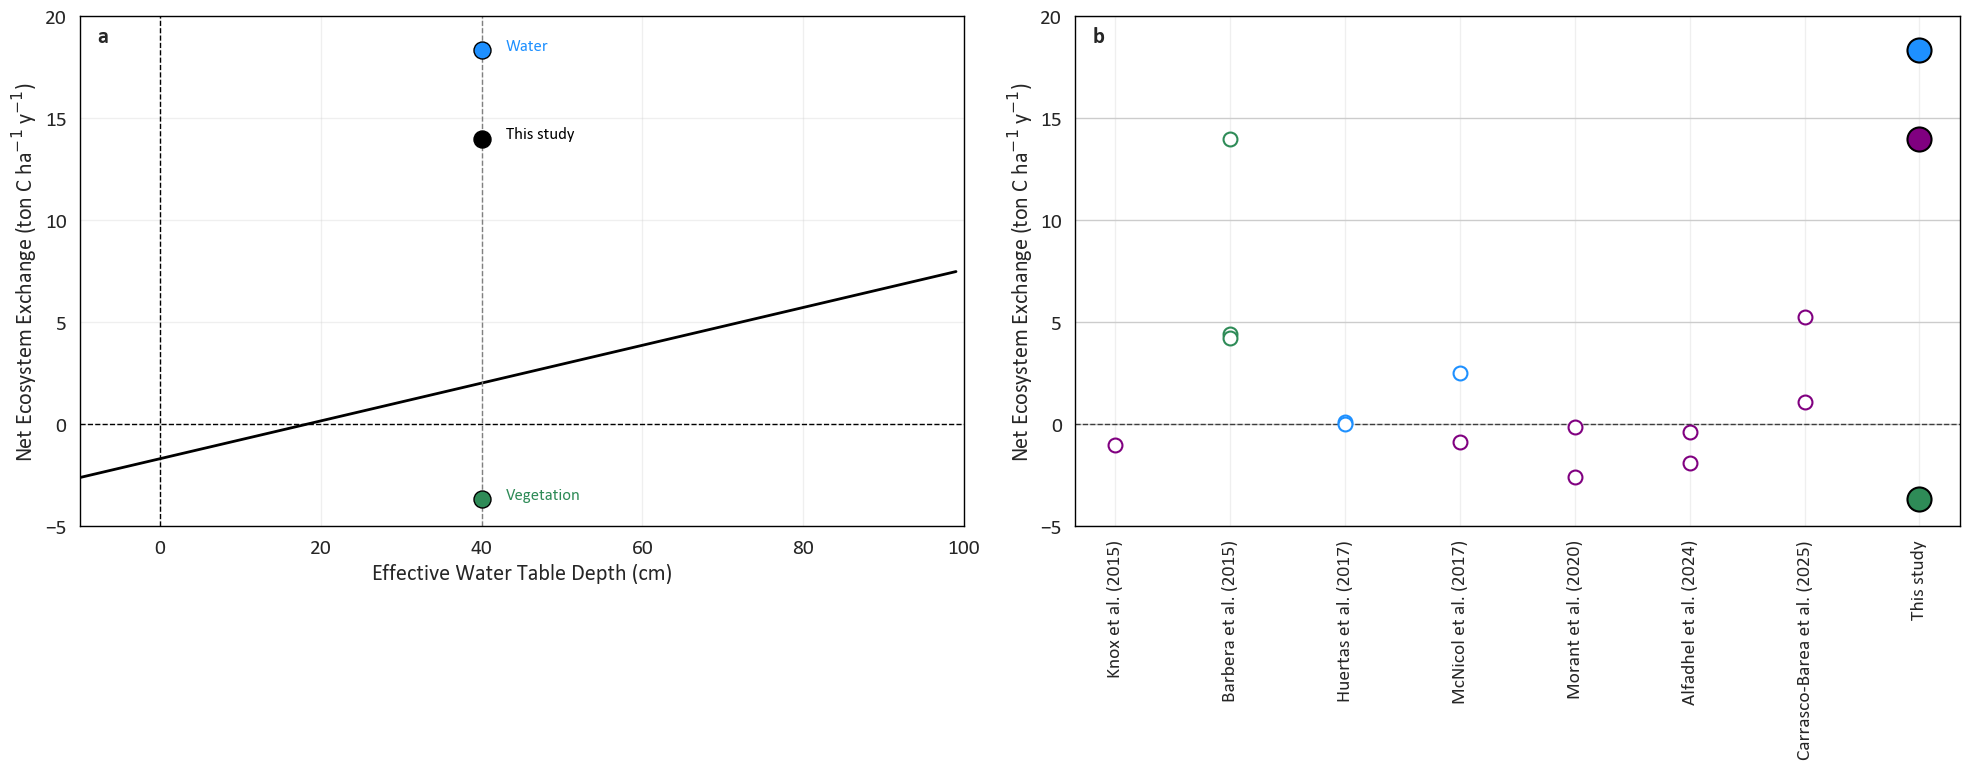

In [ ]:
# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# ==================== LEFT SUBPLOT (a): Water Table Depth Relationship ====================
ax1.plot(WTDe_fig6, nep_fig6, color='black', linewidth=2)
ax1.scatter(40, water_flux_fig6, color='dodgerblue', s=150, marker='o', zorder=5, edgecolor='black', linewidth=1)
ax1.scatter(40, veg_flux_fig6, color='seagreen', s=150, marker='o', zorder=5, edgecolor='black', linewidth=1)
ax1.scatter(40, actual_weighted_flux_fig6, color='black', s=150, marker='o', zorder=5, edgecolor='black', linewidth=1)
ax1.axhline(0, color='black', linewidth=1, linestyle='--')
ax1.axvline(0, color='black', linewidth=1, linestyle='--')
ax1.axvline(40, color='gray', linestyle='--', linewidth=1)
ax1.text(43, water_flux_fig6, 'Water', fontsize=12, color='dodgerblue')
ax1.text(43, veg_flux_fig6, 'Vegetation', fontsize=12, color='seagreen')
ax1.text(43, actual_weighted_flux_fig6, 'This study', fontsize=12, color='black')
ax1.set_xlim(-10, 100)
ax1.set_ylim(-5, 20) 
ax1.set_xlabel('Effective Water Table Depth (cm)', fontsize=16)
ax1.set_ylabel('Net Ecosystem Exchange (ton C ha$^{-1}$ y$^{-1}$)', fontsize=16)
ax1.text(0.02, 0.98, 'a', transform=ax1.transAxes, size=16, weight='bold', verticalalignment='top')
ax1.grid(True, alpha=0.3)

# ==================== RIGHT SUBPLOT (b): Literature Comparison ====================
# Plot literature comparison
for study in sorted_studies:
    study_data = plt_df[plt_df['Study'] == study]
    if study_data.empty:
        continue
    
    study_idx = sorted_studies.index(study)
    
    for j, (_, row) in enumerate(study_data.iterrows()):
        
        # --- MODIFICATION: Reverted to coloring 'This study' points by type ---
        if row['is_our_study']:
            size = 300
            edge_width = 1.5
            zorder = 10
            # Set fill color based on the data type (Water, Vegetation, or Both)
            face_color = type_colors.get(row['Type'], 'black') 
            edge_color = 'black' # Keep a black outline for emphasis
        else:
            size = 100
            edge_width = 1.5
            zorder = 5
            face_color = 'white' # Hollow for other studies
            # Set outline color based on the data type
            edge_color = type_colors.get(row['Type'], "gray")
        # --- END MODIFICATION ---
        
        ax2.scatter(
            study_idx, row['Flux'], # Plot directly at study_idx without jitter
            marker='o',
            s=size,
            facecolor=face_color,
            edgecolor=edge_color,
            linewidth=edge_width, 
            zorder=zorder
        )

# Format right subplot
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.7, linewidth=1)
ax2.set_ylabel('Net Ecosystem Exchange (ton C ha$^{-1}$ y$^{-1}$)', fontsize=16)
ax2.set_xticks(range(len(sorted_studies)))
ax2.set_xticklabels(sorted_studies, rotation=90, fontsize=14, ha='center')
ax2.text(0.02, 0.98, 'b', transform=ax2.transAxes, size=16, weight='bold', verticalalignment='top')
ax2.grid(True, axis='x', alpha=0.3)
ax2.set_ylim(-5, 20)

# Format both axes uniformly
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(1)
        spine.set_color('black')

plt.tight_layout()

# Save the combined figure
combined_save_path = f"{FIGURE_OUTPUT_DIR}/Figure-07.png"
plt.savefig(combined_save_path, dpi=300, bbox_inches='tight')
print(f"Combined figure saved to: {combined_save_path}")

plt.show()

In [ ]:
# Compute weighted mean and propagated std, then convert and print results

w_water = 1.3 / (1.3 + 0.32)
w_veg = 0.32 / (1.3 + 0.32)

# Raw statistics (µmol m⁻² s⁻¹)
water_mean = water_df['co2_flux'].mean()
veg_mean = veg_df['co2_flux'].mean()
water_std = water_df['co2_flux'].std()
veg_std = veg_df['co2_flux'].std()

# Weighted mean and propagated variance (assume independence)
total_mean_flux = w_water * water_mean + w_veg * veg_mean
total_var = (w_water**2) * (water_std**2) + (w_veg**2) * (veg_std**2)
total_std = np.sqrt(total_var)

# Conversion factor: µmol m⁻² s⁻¹ → g C m⁻² day⁻¹
umol_to_gC_m2_day = 12.01 * 1e-6 * 60 * 60 * 24

# Convert means and stds to g C m⁻² day⁻¹
water_mean_gC_m2_day = water_mean * umol_to_gC_m2_day
veg_mean_gC_m2_day = veg_mean * umol_to_gC_m2_day
total_mean_gC_m2_day = total_mean_flux * umol_to_gC_m2_day

water_std_gC_m2_day = water_std * umol_to_gC_m2_day
veg_std_gC_m2_day = veg_std * umol_to_gC_m2_day
total_std_gC_m2_day = total_std * umol_to_gC_m2_day

# Convert to ton C ha⁻¹ yr⁻¹ using existing calculate_yearly_flux (linear scaling)
water_yearly = calculate_yearly_flux(water_mean)
veg_yearly = calculate_yearly_flux(veg_mean)
total_yearly = calculate_yearly_flux(total_mean_flux)

water_yearly_std = calculate_yearly_flux(water_std)
veg_yearly_std = calculate_yearly_flux(veg_std)
total_yearly_std = calculate_yearly_flux(total_std)

# Print results
print("\nStation fluxes (µmol m⁻² s⁻¹) and their std:")
print(f"Water station: {water_mean:.4f} ± {water_std:.4f} µmol m⁻² s⁻¹")
print(f"Vegetation   : {veg_mean:.4f} ± {veg_std:.4f} µmol m⁻² s⁻¹")
print(f"Weighted total: {total_mean_flux:.4f} ± {total_std:.4f} µmol m⁻² s⁻¹")

print("\nConverted to g C m⁻² day⁻¹:")
print(f"Water station: {water_mean_gC_m2_day:.4f} ± {water_std_gC_m2_day:.4f} g C m⁻² day⁻¹")
print(f"Vegetation   : {veg_mean_gC_m2_day:.4f} ± {veg_std_gC_m2_day:.4f} g C m⁻² day⁻¹")
print(f"Weighted total: {total_mean_gC_m2_day:.4f} ± {total_std_gC_m2_day:.4f} g C m⁻² day⁻¹")

print("\nConverted to ton C ha⁻¹ yr⁻¹:")
print(f"Water station: {water_yearly:.4f} ± {water_yearly_std:.4f} ton C ha⁻¹ yr⁻¹")
print(f"Vegetation   : {veg_yearly:.4f} ± {veg_yearly_std:.4f} ton C ha⁻¹ yr⁻¹")
print(f"Weighted total: {total_yearly:.4f} ± {total_yearly_std:.4f} ton C ha⁻¹ yr⁻¹")


# First, define seasons based on months
def get_season(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'autumn'
    else:  # months 12, 1, 2
        return 'winter'

# Add season column to both dataframes
for df in [water_df, veg_df]:
    df['season'] = df.index.month.map(get_season)

# Calculate and print mean g C m⁻² day⁻¹ per season for each station
print("\nMean g C m⁻² day⁻¹ per season (Water station):")
for season in ['spring', 'summer', 'autumn', 'winter']:
    season_mask = water_df['season'] == season
    mean_umol = water_df.loc[season_mask, 'co2_flux'].mean()
    std_umol = water_df.loc[season_mask, 'co2_flux'].std()
    mean_gC = mean_umol * umol_to_gC_m2_day
    std_gC = std_umol * umol_to_gC_m2_day
    print(f"{season.capitalize():<8}: {mean_gC:.4f} ± {std_gC:.4f} g C m⁻² day⁻¹")

print("\nMean g C m⁻² day⁻¹ per season (Vegetation station):")
for season in ['spring', 'summer', 'autumn', 'winter']:
    season_mask = veg_df['season'] == season
    mean_umol = veg_df.loc[season_mask, 'co2_flux'].mean()
    std_umol = veg_df.loc[season_mask, 'co2_flux'].std()
    mean_gC = mean_umol * umol_to_gC_m2_day
    std_gC = std_umol * umol_to_gC_m2_day
    print(f"{season.capitalize():<8}: {mean_gC:.4f} ± {std_gC:.4f} g C m⁻² day⁻¹")


Station fluxes (µmol m⁻² s⁻¹) and their std:
Water station: 4.8443 ± 8.3148 µmol m⁻² s⁻¹
Vegetation   : -0.9727 ± 10.8973 µmol m⁻² s⁻¹
Weighted total: 3.6953 ± 7.0110 µmol m⁻² s⁻¹

Converted to g C m⁻² day⁻¹:
Water station: 5.0267 ± 8.6280 g C m⁻² day⁻¹
Vegetation   : -1.0093 ± 11.3078 g C m⁻² day⁻¹
Weighted total: 3.8344 ± 7.2750 g C m⁻² day⁻¹

Converted to ton C ha⁻¹ yr⁻¹:
Water station: 18.3476 ± 31.4920 ton C ha⁻¹ yr⁻¹
Vegetation   : -3.6839 ± 41.2734 ton C ha⁻¹ yr⁻¹
Weighted total: 13.9957 ± 26.5539 ton C ha⁻¹ yr⁻¹

Mean g C m⁻² day⁻¹ per season (Water station):
Spring  : 4.6592 ± 8.5147 g C m⁻² day⁻¹
Summer  : 5.1102 ± 8.8621 g C m⁻² day⁻¹
Autumn  : 5.5605 ± 8.4916 g C m⁻² day⁻¹
Winter  : 4.7476 ± 8.5583 g C m⁻² day⁻¹

Mean g C m⁻² day⁻¹ per season (Vegetation station):
Spring  : -4.3323 ± 12.4747 g C m⁻² day⁻¹
Summer  : -1.9516 ± 12.6547 g C m⁻² day⁻¹
Autumn  : 0.6559 ± 9.5510 g C m⁻² day⁻¹
Winter  : 2.1684 ± 6.9892 g C m⁻² day⁻¹
